In [1]:
# Core imports for the simulation
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import itertools
from io import StringIO

# Mesa framework imports
import mesa
from mesa.datacollection import DataCollector

In [2]:
# --- Load Demographic Distributions ---

# Try to load from CSV, otherwise use fallback data
try:
    demographic_distributions = pd.read_csv('demog_distrib.csv')
except FileNotFoundError:
    print("Warning: 'demog_distrib.csv' not found. Using fallback demographic data.")
    multiline_csv = """
    region,gender_m,gender_f,age_<19,age_20_29,age_30_39,age_40_49,age_50_59,age_60_69,age_>70,no_education,early_childhood,elementary,high_school,post_secondary,short-cycle_tertiary,college,post_baccalaureate,below_poverty_line,low_income,middle_income,high_income,urban,rural,total_pop
    NCR,0.4979455817342733,0.5020544182657267,0.10886509803868027,0.2500000731402697,0.21171816343027475,0.15869809929893589,0.11471534440924068,0.06833544156097329,0.08766778012162545,0.0023356758927292757,0.00012493558331649456,0.08077632699916809,0.43901992268242684,0.013746631256549438,0.01929686873224766,0.43718006552613214,0.007519573327430041,0.007879037641248839,0.1975561139893578,0.7778949788770704,0.016669869492323006,1.0,0.0,0.1233451341820353
    CAR,0.5122105095077328,0.4877894904922671,0.12992193112976164,0.242831056749671,0.19080093093885211,0.14060994857102052,0.11141755405580678,0.07384408668748697,0.11057449186740097,0.01956568965396418,0.0003402660927563812,0.18125048178408443,0.3781711125766864,0.022009843578820656,0.02570916670624758,0.3630358898970559,0.0099175497103845,0.06910579765655024,0.39043535623719067,0.5333413170303536,0.007117529075905631,0.32239864934426005,0.6776013506557399,0.016482651506400152
    R1,0.5065430001377473,0.4934569998622526,0.12202015954775337,0.21498626635675935,0.17906441867074685,0.14846326274766306,0.1191982413928698,0.08061945446971201,0.13564819681449555,0.005668311194643809,0.000304617236421548,0.158934637542476,0.49635436839082314,0.015501133662238929,0.024812434512578075,0.29385471052379897,0.004569786937019528,0.09002209726972163,0.4118193552339355,0.48956706061805033,0.008591486878292635,0.24278882449592773,0.7572111755040722,0.048701950967783306
    R2,0.5094055353790531,0.49059446462094686,0.12316046136385732,0.22578753175179453,0.18399819950009064,0.1526646579602145,0.12033578468642064,0.08004532587588302,0.11400803886173934,0.012487267341336846,0.0005931404245632703,0.24312531915194288,0.4046069403922518,0.012806180576694432,0.021324410382898305,0.2994060575181981,0.005650684212114349,0.10573693533789608,0.471369186857916,0.4161482319481325,0.006745645856055394,0.21955029816187735,0.7804497018381227,0.03386259438383724
    R3,0.5063281155968556,0.49367188440314436,0.1232473227561026,0.23557628968814107,0.18948151978825006,0.1543669145865521,0.11804329358744693,0.07327388560097046,0.10601077399253674,0.0058473168992824376,0.0003866259967916463,0.17592572102824627,0.4800070675048761,0.012459745090554987,0.02836025516857157,0.2939576387700111,0.0030556295416658877,0.032107662133616384,0.33072789724684176,0.6330420915323657,0.004122349087176123,0.6755929049657982,0.3244070950342019,0.11399786593990599
    CALABARZON,0.5027331244497288,0.49726687555027116,0.11114056959760212,0.2213749316394275,0.20543589966898138,0.16919651814297532,0.12299255786400219,0.08453509594369493,0.08532442714331658,0.004872245416521201,0.00023125810441622542,0.13801684765564173,0.4797254839523925,0.01091249726665161,0.025359527663409206,0.3370949278234276,0.00378721211753997,0.046902417816506746,0.31023967348674913,0.6302123439009523,0.012645564795791866,0.6943289381154611,0.30567106188453896,0.14852497642730556
    MIMAROPA,0.51017359283277,0.4898264071672301,0.14638108456094628,0.23568265457629567,0.18024750199274006,0.14593820537916558,0.11117305460778161,0.07210107679326062,0.10847642208981019,0.03051349955862023,0.0005797157773373234,0.2646923018556457,0.4300269639549108,0.010586174542103189,0.020420522956374653,0.23969188545963643,0.003488935895371712,0.20570233403603244,0.4890585714236833,0.29771963602880713,0.007519458511477085,0.3306238294211009,0.669376170578899,0.02956082093813853
    R5,0.5073553431597962,0.49264465684020375,0.15514038204010264,0.22555568060781925,0.1699485895386247,0.14154758933799738,0.11395072956345031,0.07521660644351595,0.11864042246848974,0.007505001076228594,0.0004232162326379743,0.2629793419301169,0.45112191186365164,0.017062111685935924,0.018470741885261488,0.23794962648094323,0.004488048845224279,0.17321855003434222,0.5091674807903452,0.31267545456022305,0.004938514615089359,0.2582708578808103,0.7417291421191897,0.055833763692272366
    R6,0.5076864006184041,0.49231359938159586,0.12213057449970258,0.2188264823444452,0.17860843015152147,0.14295517352643558,0.11694321950748389,0.08212187128906293,0.13841424868134836,0.010436084968807493,0.00040969103230655154,0.21690170214690305,0.42345722524141804,0.015873329203523308,0.03850377891973645,0.29037834419502084,0.004039844292284314,0.12803623163646435,0.4358203242840371,0.4270088448395545,0.00913459923994402,0.21144594579790293,0.7885540542020971,0.04342847536580157
    NIR,0.5082974960359194,0.49170250396408055,0.13094469550247473,0.2243010711745189,0.17712571920769893,0.14323375050697185,0.1193170836960742,0.08193039875245986,0.12314728115980156,0.011015955373991604,0.0003737142801754985,0.23284966472515936,0.4246473004169194,0.00989068408560534,0.02468093829208984,0.29284785897796506,0.0036938838480939404,0.24358753104417596,0.47548455836475007,0.27583081786826386,0.005097092722810101,0.33301873284458366,0.6669812671554163,0.04274373233842389
    R7,0.5068583112323745,0.49314168876762554,0.13004801380778602,0.24042033961780276,0.18929082445752946,0.14600451439701861,0.10997665458349701,0.07220775995945591,0.11205189317691022,0.011595942120474202,0.0003375401973568807,0.24880554758086915,0.42583819938822637,0.00390505281516604,0.01085119917439104,0.2953187663193055,0.00334775240421085,0.11690171801648853,0.40573942716715955,0.47140033233510575,0.0059585224812461314,0.5762886172853698,0.42371138271463016,0.06089920933985477
    R8,0.5122731662191339,0.48772683378086606,0.1446795794455623,0.22421354951651257,0.166188094140928,0.14123803543455132,0.11585592928349155,0.07867017794783822,0.129154634231116,0.01799582900901314,0.000400402039005641,0.29970010771240463,0.40876792069224044,0.0036648409032127107,0.010169491525423728,0.25366893331980106,0.005632474798898649,0.21966221551148132,0.4803362435729889,0.2950928226291966,0.004908718286333194,0.1476029511371409,0.8523970488628592,0.04170088625674667
    R9,0.5090372051070422,0.4909627948929578,0.14503113771578693,0.24297151136837639,0.18020468200013173,0.14536337092300824,0.11155827619263671,0.07194605235234283,0.10292496944771717,0.029185505608632378,0.0002955919316288443,0.2857272830571937,0.393302441308211,0.0034897028969180736,0.011189150331340204,0.273251116865023,0.003559208001052729,0.2542960712782039,0.47801243683732725,0.26182176824673514,0.005869723637733729,0.34397705300803794,0.6560229469919621,0.03554516524389092
    R10,0.5101931028368157,0.4898068971631843,0.14073799697607595,0.2439310900280151,0.188339526461582,0.1459635893484185,0.11161054284603823,0.07113298301345489,0.0982842713264153,0.014341013703721631,0.0003316428511246278,0.24178048589561796,0.4436141422072595,0.010318574330126257,0.010118991064764769,0.27564630021027947,0.0038488497371058157,0.18319364000128738,0.46446158851128544,0.3451518932184898,0.007192878268937313,0.49601921866813276,0.5039807813318673,0.046083871077636666
    R11,0.5128402646195243,0.48715973538047574,0.13058041979688534,0.24011852989768717,0.1962241155246779,0.15062903426359786,0.11132167236703555,0.07257778918026439,0.09854843896985178,0.01730847666675333,0.00041597372656269,0.2319447694239183,0.4469455982962969,0.018769696202199013,0.01396251595893825,0.2671661146907775,0.003486855034554054,0.16277831605038648,0.4516469936679358,0.3795809467604981,0.005993743521179788,0.6524961526575077,0.3475038473424923,0.04807163106481144
    R12,0.5113835211533322,0.48861647884666776,0.1435630684131719,0.24943475777842244,0.1952118324905652,0.1514985748610961,0.10744903388461254,0.06403921180907432,0.08880352076305749,0.0369208099580148,0.0004052200048543773,0.23965888531791868,0.4387000597329404,0.008714467937870856,0.023828106844499836,0.24803595682014187,0.0037364933837591816,0.26329501636485886,0.43857768824426535,0.29249304502056406,0.005634250370311678,0.5691981966801013,0.43080180331989865,0.04004685210768089
    CARAGA,0.5131365057560082,0.4868634942439918,0.1434141510962909,0.23334177542676765,0.18028049227151954,0.14179991049068058,0.1158962306465834,0.07457474399888585,0.11069269606927208,0.012695845257123169,0.0003807105249445152,0.25786970129111914,0.4455376579071343,0.00471953438464737,0.017164408457728902,0.257931380649909,0.003700761527393611,0.22445937136026733,0.6080233410784973,0.1672426834518992,0.0002746041093362262,0.27204281936635477,0.7279571806336452,0.025723898643308072
    BARMM,0.5011411269608279,0.4988588730391721,0.18397657969940906,0.30246602935857875,0.20396207285495638,0.14755346295554478,0.07691412176221256,0.037708737186571306,0.04741899618272719,0.1423020665604911,0.0006437259546582335,0.31126976963882164,0.3435315725982753,0.0006851660324812949,0.0014518074722079308,0.19893414715090685,0.0011817445921576408,0.24733151767736583,0.43506126510414617,0.31042006462874194,0.0071871525897459505,0.6315478053167597,0.36845219468324025,0.04544652052416665
    """
    demographic_distributions = pd.read_csv(StringIO(multiline_csv))

# --- Split into Separate DataFrames for Each Demographic Category ---
region_cols = demographic_distributions[['region', 'total_pop']]
gender_cols = demographic_distributions[['gender_m', 'gender_f']]
age_cols = demographic_distributions[['age_<19', 'age_20_29', 'age_30_39', 'age_40_49', 'age_50_59', 'age_60_69', 'age_>70']]
educ_cols = demographic_distributions[['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']]
income_cols = demographic_distributions[['below_poverty_line', 'low_income', 'middle_income', 'high_income']]
split_cols = demographic_distributions[['urban', 'rural']]

# --- Define Issues and Labels ---
issues = {
    'gov': 'Governance',
    'edu': 'Education',
    'labor': 'Labor',
    'sec': 'Security',
    'energy': 'Energy',
    'env': 'Environment',
    'health': 'Health',
    'econ': 'Economy',
    'agri': 'Food & Agriculture',
    'crime': 'Anti-Drugs & Crime'
}

# --- Define Turnout Probabilities by Region ---
turnout_prob = [
    0.8143, # NCR
    0.8546, # CAR
    0.8754, # R1
    0.8438, # R2
    0.8648, # R3
    0.8306, # CALABARZON
    0.8389, # MIMAROPA
    0.8610, # R5
    0.8519, # R6
    0.8657, # NIR
    0.8675, # R7
    0.8548, # R8
    0.8167, # R9
    0.8561, # R10
    0.8124, # R11
    0.8066, # R12
    0.8533, # CARAGA
    0.7754, # BARMM
]

# --- Model Constants for Modifiers ---
likely_modifier = 1.25
slightly_likely_modifier = 1.1
neutral_modifier = 1.0
slightly_unlikely_modifier = 0.9
unlikely_modifier = 0.75

# --- Vote Buying Parameters ---
VOTE_BUYING_GLOBAL_THROTTLE = 0.5
VOTE_BUYING_THRESHOLD = 0.08


# Voter Class

In [3]:
class VoterAgent(mesa.Agent):
    """A Voter agent with demographic attributes and voting behavior."""

    def __init__(self, id, model, influence_factor=1):
        """Initialize a voter agent with demographic attributes and voting behavior."""
        super().__init__(id, model)
        self.approval_threshold = np.random.uniform(0.4, 0.7)  # Approval threshold for voting
        self.ranked_vote = []                                  # Store Candidate by Rankings
        self.approval_scores = {}                              # Store Approval Scores for Candidates
        self.will_vote = False                                 # Flag for voting
        self.influence_factor = influence_factor               # Boost from vote buying

        # Initialize demographic attributes
        self._initialize_demographics()
        # Initialize Turnout Probability
        self._initialize_turnout_probability()
        # Developing Issue Stances and Priorities
        self.issue_stances = {}
        self.issue_priorities = {}
        self._initialize_issue_stances_and_priorities()
        # Develop Vote Buying Susceptibility
        self._initialize_vote_buying_susceptibility()
        # Initialize acceptance threshold for vote buying
        self._initialize_acceptance_threshold()

        # Issue evaluation weight (default: 100% weight to issues)
        self.issue_weight = 1.0
        self.vote_buying_weight = 0.0  # Will be set during evaluation based on susceptibility

    def _initialize_demographics(self):
        """Set demographic attributes based on distributions."""
        try:
            # Region
            region_probs = region_cols['total_pop']
            self.region_idx = np.random.choice(range(18), p=region_probs)
            self.region = region_cols['region'][self.region_idx]

            # Gender
            self.gender = np.random.choice(
                ['m', 'f'],
                p=list(gender_cols.iloc[self.region_idx, :].astype(float).values)
            )

            # Age Group
            self.age_group = np.random.choice(
                ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70'],
                p=list(age_cols.iloc[self.region_idx, :].astype(float).values)
            )

            # Education Attainment
            self.educ_attainment = np.random.choice(
                [
                    'no_education', 'early_childhood', 'elementary', 'high_school',
                    'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate'
                ],
                p=list(educ_cols.iloc[self.region_idx, :].astype(float).values)
            )

            # Income Group
            self.income_group = np.random.choice(
                ['below_poverty_line', 'low_income', 'middle_income', 'high_income'],
                p=list(income_cols.iloc[self.region_idx, :].astype(float).values)
            )

            # Urban/Rural Split
            self.split = np.random.choice(
                ['urban', 'rural'],
                p=list(split_cols.iloc[self.region_idx, :].astype(float).values)
            )
        except Exception:
            self.region = 'Unknown'
            self.gender = 'Unknown'
            self.age_group = 'Unknown'
            self.educ_attainment = 'Unknown'
            self.income_group = 'Unknown'
            self.split = 'Unknown'

    def _initialize_issue_stances_and_priorities(self):
        """Initialize issue stances and priorities based on demographic attributes."""
        self.issues = list(issues.keys())

        # Stance Definitions:
        # 0 = Conservative (Status Quo), 1 = Liberal (Reform)
        base_priorities = {issue: 1.0 for issue in self.issues}
        stance_a = {issue: 2.0 for issue in self.issues}  # Beta(a, b) parameters
        stance_b = {issue: 2.0 for issue in self.issues}
        stance_bias_strength = 0.5  # Strength of bias

        # Add noise for issue priorities
        for issue in self.issues:
            base_priorities[issue] += np.random.normal(0, 0.05)

        # --- Demographic Effects ---
        # Age Group Effects
        if self.age_group in ['<19', '20-29']:
            # Priorities
            base_priorities['gov'] *= likely_modifier
            base_priorities['edu'] *= likely_modifier
            base_priorities['econ'] *= likely_modifier
            base_priorities['health'] *= likely_modifier
            base_priorities['energy'] *= likely_modifier
            base_priorities['crime'] *= slightly_likely_modifier
            # Stances (Bias towards reform)
            stance_a['gov'] += stance_bias_strength
            stance_b['gov'] -= stance_bias_strength * 0.5
            stance_a['edu'] += stance_bias_strength * 0.5
            stance_b['edu'] -= stance_bias_strength * 0.25
            stance_a['health'] += stance_bias_strength * 0.25
            stance_b['health'] -= stance_bias_strength * 0.1
            stance_a['energy'] += stance_bias_strength
            stance_b['energy'] -= stance_bias_strength * 0.5
            stance_a['crime'] += stance_bias_strength
            stance_b['crime'] -= stance_bias_strength * 0.5

        elif self.age_group in ['50-59', '60-69', '>70']:
            base_priorities['gov'] *= slightly_unlikely_modifier
            base_priorities['health'] *= likely_modifier
            base_priorities['sec'] *= slightly_likely_modifier
            base_priorities['crime'] *= slightly_likely_modifier
            base_priorities['econ'] *= slightly_likely_modifier
            # Stances (Bias towards status quo)
            stance_a['gov'] -= stance_bias_strength * 0.5
            stance_b['gov'] += stance_bias_strength
            stance_a['health'] += stance_bias_strength
            stance_b['health'] -= stance_bias_strength * 0.5
            stance_a['sec'] -= stance_bias_strength
            stance_b['sec'] += stance_bias_strength * 0.5
            stance_a['crime'] -= stance_bias_strength
            stance_b['crime'] += stance_bias_strength * 0.5
            stance_a['econ'] -= stance_bias_strength * 0.5
            stance_b['econ'] += stance_bias_strength * 0.25

        # Income Effects
        if self.income_group in ['below_poverty_line', 'low_income']:
            base_priorities['econ'] *= likely_modifier
            base_priorities['labor'] *= likely_modifier
            base_priorities['agri'] *= likely_modifier
            base_priorities['health'] *= likely_modifier
            base_priorities['env'] *= slightly_likely_modifier
            base_priorities['sec'] *= slightly_likely_modifier
            base_priorities['crime'] *= slightly_likely_modifier
            # Stances (Bias towards liberal)
            stance_a['econ'] += stance_bias_strength
            stance_b['econ'] -= stance_bias_strength * 0.5
            stance_a['labor'] += stance_bias_strength
            stance_b['labor'] -= stance_bias_strength * 0.5
            stance_a['agri'] += stance_bias_strength
            stance_b['agri'] -= stance_bias_strength * 0.5
            stance_a['health'] += stance_bias_strength
            stance_b['health'] -= stance_bias_strength * 0.5

        elif self.income_group == 'middle_income':
            base_priorities['econ'] *= likely_modifier
            base_priorities['labor'] *= likely_modifier
            base_priorities['gov'] *= slightly_likely_modifier
            # Stances (Bias towards populist gov support)
            stance_a['gov'] -= stance_bias_strength * 0.5
            stance_b['gov'] += stance_bias_strength * 0.25

        elif self.income_group == 'high_income':
            base_priorities['econ'] *= likely_modifier
            base_priorities['env'] *= likely_modifier
            # Stances (Bias towards conservative econ, env care)
            stance_a['econ'] -= stance_bias_strength
            stance_b['econ'] += stance_bias_strength * 0.5
            stance_a['gov'] -= stance_bias_strength * 0.25
            stance_b['gov'] += stance_bias_strength * 0.1
            stance_a['env'] += stance_bias_strength
            stance_b['env'] -= stance_bias_strength * 0.5

        # Urban/Rural Effects
        if self.split == 'urban':
            base_priorities['sec'] *= likely_modifier
            base_priorities['labor'] *= likely_modifier
            base_priorities['env'] *= likely_modifier
            base_priorities['econ'] *= likely_modifier
            base_priorities['agri'] *= unlikely_modifier
            if self.region == 'NCR':
                base_priorities['gov'] *= slightly_likely_modifier
            # Stances
            stance_a['sec'] -= stance_bias_strength * 0.5
            stance_b['sec'] += stance_bias_strength * 0.25
            stance_a['labor'] += stance_bias_strength * 0.25
            stance_b['labor'] -= stance_bias_strength * 0.1
            stance_a['env'] += stance_bias_strength * 0.5
            stance_b['env'] -= stance_bias_strength * 0.25
            if self.region == 'NCR':
                stance_a['gov'] += stance_bias_strength
                stance_b['gov'] -= stance_bias_strength * 0.5

        elif self.split == 'rural':
            base_priorities['labor'] *= likely_modifier
            base_priorities['energy'] *= likely_modifier
            base_priorities['env'] *= likely_modifier
            base_priorities['health'] *= likely_modifier
            base_priorities['econ'] *= likely_modifier
            base_priorities['agri'] *= likely_modifier
            # Stances
            stance_a['energy'] += stance_bias_strength * 0.5
            stance_b['energy'] -= stance_bias_strength * 0.25
            stance_a['env'] -= stance_bias_strength * 0.5
            stance_b['env'] += stance_bias_strength * 0.25
            stance_a['health'] += stance_bias_strength
            stance_b['health'] -= stance_bias_strength * 0.5
            stance_a['agri'] += stance_bias_strength
            stance_b['agri'] -= stance_bias_strength * 0.5

        # Gender Effects
        if self.gender == 'f':
            base_priorities['env'] *= slightly_likely_modifier
            base_priorities['sec'] *= slightly_likely_modifier
            base_priorities['health'] *= slightly_likely_modifier
            stance_a['env'] += stance_bias_strength
            stance_b['env'] -= stance_bias_strength * 0.5

        # Education Effects
        if self.educ_attainment in ['college', 'post_baccalaureate']:
            base_priorities['edu'] *= slightly_likely_modifier
            base_priorities['energy'] *= slightly_likely_modifier
            base_priorities['health'] *= slightly_likely_modifier
            base_priorities['env'] *= slightly_likely_modifier
            stance_a['edu'] += stance_bias_strength
            stance_b['edu'] -= stance_bias_strength * 0.5
            stance_a['energy'] += stance_bias_strength
            stance_b['energy'] -= stance_bias_strength * 0.5
            stance_a['health'] += stance_bias_strength * 0.5
            stance_b['health'] -= stance_bias_strength * 0.25
            stance_a['env'] += stance_bias_strength * 0.5
            stance_b['env'] -= stance_bias_strength * 0.25
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']:
            base_priorities['sec'] *= slightly_likely_modifier
            base_priorities['energy'] *= unlikely_modifier
            base_priorities['env'] *= unlikely_modifier

        # --- Final Stance Generation and Priority Normalization ---
        final_stances = {}
        for issue in self.issues:
            a = max(0.1, stance_a[issue])
            b = max(0.1, stance_b[issue])
            final_stances[issue] = np.random.beta(a, b)
        self.issue_stances = final_stances

        total_priority = sum(base_priorities.values())
        if total_priority > 0:
            self.issue_priorities = {k: max(0.0, v) / total_priority for k, v in base_priorities.items()}
        else:
            self.issue_priorities = {issue: 1.0 / len(self.issues) for issue in self.issues}

    def _initialize_turnout_probability(self):
        """Initialize turnout probability based on region and demographics."""
        self.turnout_probability = 0.0
        if self.region_idx != -1 and self.region_idx < len(turnout_prob):
            base_rate = turnout_prob[self.region_idx]
            turnout_modifier = 1.0

            # Gender
            if self.gender == 'f':
                turnout_modifier *= 1.05
            elif self.gender == 'm':
                turnout_modifier *= 0.95

            # Age
            if self.age_group in ['<19', '20-29']:
                turnout_modifier *= 1.02
            elif self.age_group in ['50-59', '60-69', '>70']:
                turnout_modifier *= 0.95

            self.turnout_probability = max(0.0, min(1.0, base_rate * turnout_modifier))
        else:
            self.turnout_probability = 0.83

    def _initialize_vote_buying_susceptibility(self):
        """Initialize susceptibility to vote buying based on demographics."""
        base_susceptibility = 0.1
        modifier = 1

        # Income Effect
        if self.income_group == 'below_poverty_line':
            modifier *= 2.5
        elif self.income_group == 'low_income':
            modifier *= 1.8
        elif self.income_group == 'middle_income':
            modifier *= 1.2
        elif self.income_group == 'high_income':
            modifier *= 0.5

        # Education Effect
        if self.educ_attainment in ['no_education', 'early_childhood', 'elementary']:
            modifier *= 1.5
        elif self.educ_attainment in ['college', 'post_baccalaureate']:
            modifier *= 0.7

        # Add some individual random variation
        final_susceptibility = base_susceptibility * modifier * np.random.uniform(0.9, 1.1)
        self.vote_buying_susceptibility = max(
            0.0, min(1.0, final_susceptibility * self.influence_factor)
        )

    def _initialize_acceptance_threshold(self):
        """Initialize threshold for accepting vote buying offers."""
        base_threshold = 0.08 * (1.0 - self.vote_buying_susceptibility)

        # Income modifications
        income_modifier = 1.0
        if self.income_group == 'below_poverty_line':
            income_modifier = 0.6
        elif self.income_group == 'low_income':
            income_modifier = 0.8
        elif self.income_group == 'high_income':
            income_modifier = 1.5

        # Education modifications
        education_modifier = 1.0
        if self.educ_attainment in ['college', 'post_baccalaureate']:
            education_modifier = 1.3
        elif self.educ_attainment in ['no_education', 'early_childhood', 'elementary']:
            education_modifier = 0.7

        threshold = base_threshold * income_modifier * education_modifier
        threshold *= np.random.uniform(0.9, 1.1)
        self.acceptance_threshold = max(0.01, min(0.15, threshold))

    def evaluate_candidate(self, candidate):
        """Evaluate a candidate based on their issue stances and the voter's priorities."""
        issue_score = self.get_issue_score(candidate)
        return max(0.0, min(1.0, issue_score))

    def adapt_to_winner(self, winner_agent, satisfaction_score):
        """
        Adapt issue stances and priorities based on election winner and voter satisfaction.
        """
        if not hasattr(winner_agent, 'issue_stances') or not hasattr(winner_agent, 'issue_priorities'):
            return

        learning_rate = 0.05
        direction = 2 * (satisfaction_score - 0.5)  # Range: -1 to 1

        # Update issue stances
        for issue in self.issues:
            if issue in winner_agent.issue_stances and issue in self.issue_stances:
                winner_stance = winner_agent.issue_stances[issue]
                voter_stance = self.issue_stances[issue]
                update = learning_rate * direction * (winner_stance - voter_stance)
                noise = np.random.normal(0, 0.01)
                self.issue_stances[issue] = max(0.0, min(1.0, voter_stance + update + noise))

        # Update issue priorities
        for issue in self.issues:
            if issue in winner_agent.issue_priorities and issue in self.issue_priorities:
                winner_priority = winner_agent.issue_priorities[issue]
                voter_priority = self.issue_priorities[issue]
                update = learning_rate * direction * (winner_priority - voter_priority)
                noise = np.random.normal(0, 0.01)
                self.issue_priorities[issue] = max(0.0, voter_priority + update + noise)

        # Normalize priorities to sum to 1
        total_priority = sum(self.issue_priorities.values())
        if total_priority > 0:
            for issue in self.issue_priorities:
                self.issue_priorities[issue] /= total_priority

    def step(self):
        """Evaluate candidates, potentially accept vote buying offers, and rank candidates."""
        candidates = [c for c in self.model.schedule.agents if isinstance(c, CandidateAgent)]
        if not candidates:
            self.initial_approval_scores = {}
            self.approval_scores = {}
            self.ranked_vote = []
            return

        # 1. Initial Evaluation - based on issues only
        initial_scores = {c: self.evaluate_candidate(c) for c in candidates}
        final_scores = initial_scores.copy()

        # 2. Simulate Vote Buying Offers and Acceptance
        vote_buying_offers = {}
        shuffled_candidates = list(candidates)
        np.random.shuffle(shuffled_candidates)

        for candidate in shuffled_candidates:
            if hasattr(candidate, 'vote_buying_propensity'):
                if candidate.vote_buying_propensity <= 0:
                    continue

                target_threshold = 0.5
                if self.vote_buying_susceptibility >= target_threshold:
                    propensity_modifier = 1.1
                else:
                    propensity_modifier = 0.5

                adjusted_propensity = candidate.vote_buying_propensity * propensity_modifier
                adjusted_propensity = min(1.0, adjusted_propensity)

                # Global throttle for vote buying (if present)
                adjusted_propensity *= VOTE_BUYING_GLOBAL_THROTTLE

                if (adjusted_propensity >= VOTE_BUYING_THRESHOLD and
                        np.random.random() <= adjusted_propensity):
                    min_offer = 0.05 * self.influence_factor
                    max_offer = 0.35 * self.influence_factor
                    propensity_weight = candidate.vote_buying_propensity ** 0.75
                    uniform_component = np.random.uniform(min_offer, max_offer)
                    weighted_component = min_offer + (max_offer - min_offer) * propensity_weight
                    offer_value = 0.1 * uniform_component + 0.9 * weighted_component

                    if offer_value >= self.acceptance_threshold:
                        if np.random.random() < self.vote_buying_susceptibility:
                            vote_buying_offers[candidate] = offer_value
                            candidate.engaged_in_vote_buying = True
                            self.will_vote = True

        # 3. Calculate final scores with weighted combination of issue score and vote buying
        for candidate, issue_score in initial_scores.items():
            if candidate in vote_buying_offers:
                self.vote_buying_weight = min(0.95, self.vote_buying_susceptibility ** 0.6)
                self.issue_weight = 1.0 - self.vote_buying_weight
                weighted_score = (
                    self.issue_weight * issue_score +
                    self.vote_buying_weight * (issue_score + vote_buying_offers[candidate])
                )
                final_scores[candidate] = max(0.0, min(1.0, weighted_score))

        # 4. Store initial and final scores, then rank
        self.initial_approval_scores = {c.unique_id: s for c, s in initial_scores.items()}
        self.approval_scores = {c.unique_id: s for c, s in final_scores.items()}
        sorted_candidates = sorted(final_scores.items(), key=lambda item: item[1], reverse=True)
        self.ranked_vote = [candidate for candidate, score in sorted_candidates]

    def get_issue_score(self, candidate):
        """Calculates the issue alignment score (0-1) for a candidate."""
        issue_score = 0.0
        if hasattr(candidate, 'issue_stances') and self.issue_stances and self.issue_priorities:
            for issue in self.issues:
                voter_stance = self.issue_stances.get(issue, 0.5)
                candidate_stance = candidate.issue_stances.get(issue, 0.5)
                priority = self.issue_priorities.get(issue, 0.0)
                alignment = 1.0 - abs(voter_stance - candidate_stance)
                issue_score += alignment * priority
        return issue_score


# Candidate Class

In [12]:
class CandidateAgent(mesa.Agent):
    """A Candidate Agent with a Political Position."""
    def __init__(self, id, model, influence_factor=1, politician_type=None):
        super().__init__(id, model)
        self.vote_count = 0         # Tracks first-choice votes
        self.engaged_in_vote_buying = False # Flag for vote buying
        self.influence_factor = influence_factor # Boost from vote buying

        # Politician Types
        types = [
            'Populist', 'Liberal',
            'Conservative', 'Progressive'
        ]

        # Use specified type if provided, otherwise choose randomly
        if politician_type is not None and politician_type in types:
            self.politician_type = politician_type
        else:
            self.politician_type = np.random.choice(types)

        # Initialize issue stances dictionary
        self.issue_stances = {}
        self._initialize_issue_stances()

        # Initialize vote buying propensity
        self.vote_buying_propensity = 0.0 # Likelihood of offering to buy votes (0-1)
        self._initialize_vote_buying_propensity()

    def _initialize_issue_stances(self):
        """Set initial issue stances based on the candidate's politician type."""
        issues = [
            'gov', 'edu', 'labor', 'sec', 'energy', 'env',
            'health', 'econ', 'agri', 'crime'
        ]
        stances = {} # Temporary dict to hold base scores

        # Stance Definitions (User Provided):
        # 0=StrictGov, PrivateEdu, LessLaborRights, TightSecurity, TradEnergy, LessEnvCare, PrivateHealth, ConservativeEcon, ConservativeAgri, PunitiveCrime
        # 1=GoodGov, Free/PublicEdu, MoreLaborRights, LessSecurity/Open, RenewableEnergy, MoreEnvCare, PublicHealth, LiberalEcon, LiberalAgri, RehabCrime

        if self.politician_type == 'Populist':
            stances = { # Leans towards 0 for gov, env; leans towards 1 for agri, labor, econ (national growth); high for sec, crime (punitive)
                'gov': 0.2,
                'edu': 0.6,
                'labor': 0.7,
                'sec': 0.1,
                'energy': 0.6,
                'env': 0.3,
                'health': 0.6,
                'econ': 0.3,
                'agri': 0.8,
                'crime': 0.1
            }
        elif self.politician_type == 'Liberal':
            stances = { # Leans towards 1 for gov, edu, energy, env, health; balanced for others
                'gov': 0.9,
                'edu': 0.8,
                'labor': 0.5,
                'sec': 0.7,
                'energy': 0.8,
                'env': 0.7,
                'health': 0.8,
                'econ': 0.6,
                'agri': 0.6,
                'crime': 0.5
            }
        elif self.politician_type == 'Conservative':
            stances = { # Leans towards 0 for edu, labor, env, econ, agri, crime; mid/low for gov, health, energy; high for sec
                'gov': 0.4,
                'edu': 0.3,
                'labor': 0.2,
                'sec': 0.2,
                'energy': 0.4,
                'env': 0.2,
                'health': 0.4,
                'econ': 0.2,
                'agri': 0.3,
                'crime': 0.2
            }
        elif self.politician_type == 'Progressive':
            stances = { # Leans towards 1 for edu, labor, energy, env, health, econ, agri, crime (rehab); mid for gov, sec (human rights focus)
                'gov': 0.7,
                'edu': 0.9,
                'labor': 0.9,
                'sec': 0.6,
                'energy': 0.9,
                'env': 0.9,
                'health': 0.9,
                'econ': 0.9,
                'agri': 0.9,
                'crime': 0.8
            }


        # Apply random variation and clamp between 0 and 1
        for issue in issues:
            base_stance = stances.get(issue, 0.5) # Default to 0.5 if issue missing
            variation = np.random.uniform(-0.25, 0.25) # Add some noise
            self.issue_stances[issue] = max(0.0, min(1.0, base_stance + variation))        

    def _initialize_vote_buying_propensity(self):
        """Set likelihood of engaging in vote buying based on type."""
        # Example: Conservative and Populist types are more likely
        if self.politician_type in ['Conservative', 'Populist']:
            self.vote_buying_propensity = np.random.uniform(0.4, 0.8) # Higher chance
        else:
            self.vote_buying_propensity = np.random.uniform(0.0, 0.2) # Lower chance
        self.vote_buying_propensity = max(0.0, min(1.0, self.vote_buying_propensity * self.influence_factor * VOTE_BUYING_GLOBAL_THROTTLE)) # Clamp

    def adapt_post_election(self, median_voter_stances, did_win, learning_rate=0.05):
        """
        Adjust candidate's issue stances after the election.

        Args:
            median_voter_stances (dict): Median voter stance for each issue.
            did_win (bool): True if candidate won, False if lost.
            learning_rate (float): How much to adjust stances.
        """
        for issue, stance in self.issue_stances.items():
            median_stance = median_voter_stances.get(issue, 0.5)
            noise = np.random.normal(0, 0.01)
            if not did_win:
                # Move toward the median voter
                update = learning_rate * (median_stance - stance) + noise
                new_stance = stance + update
            else:
                # Move further away from the median voter in the same direction
                direction = np.sign(stance - median_stance)
                # If stance == median, pick a random direction
                if direction == 0:
                    direction = np.random.choice([-1, 1])
                update = learning_rate * direction + noise
                new_stance = stance + update
            # Clamp to [0, 1]
            self.issue_stances[issue] = max(0.0, min(1.0, new_stance))

    def step(self):
        # No action yet for this version
        pass

# Election Class

In [13]:
class ElectionModel(mesa.Model):
    """Election Model. Runs Both Plurality Voting and IRV for Comparison."""
    def __init__(self, num_voters, num_candidates, influence=1, verbose=False):
        super().__init__()
        self.num_voters = num_voters
        self.num_candidates = num_candidates
        self.plurality_winner = None    # Track plurality winner
        self.irv_winner = None          # Track IRV winner
        self.approval_winner = None     # Track Approval winner
        self.borda_winner = None        # Track Borda winner
        self.condorcet_winner = None    # Track Condorcet winner
        self.voters_turnout_count = 0   # Track number of voters who turned out
        self.verbose = verbose          # Verbose output flag

        # Parameter for vote buying effect - renamed from influence_factor to influence
        self.influence_factor = influence  # Keeping the same internal name for compatibility
        
        # Activate agents randomly
        self.schedule = mesa.time.RandomActivation(self)
        
        # Create Voters
        for i in range(self.num_voters):
            v = VoterAgent(f"v{i}", self, influence_factor=self.influence_factor)
            self.schedule.add(v)

        # Create Candidates with guaranteed representation of all politician types
        politician_types = ['Populist', 'Liberal', 'Conservative', 'Progressive']
        
        # Create Candidates
        # First create one candidate of each type
        for i, pol_type in enumerate(politician_types):
            c = CandidateAgent(f"c{i}", self, influence_factor=self.influence_factor, politician_type=pol_type)
            self.schedule.add(c)
            
        # Then create remaining candidates with random types
        for i in range(len(politician_types), self.num_candidates):
            c = CandidateAgent(f"c{i}", self, influence_factor=self.influence_factor)
            self.schedule.add(c)

        # Initialize DataCollector
        self.datacollector = DataCollector(
            model_reporters={
                "Turnout Percentage": lambda m: (m.voters_turnout_count / m.num_voters) * 100 if m.num_voters > 0 else 0,
                "Plurality Winner": lambda m: getattr(m.plurality_winner, 'unique_id', None),
                "IRV Winner": lambda m: getattr(m.irv_winner, 'unique_id', None),
                "Approval Winner": lambda m: getattr(m.approval_winner, 'unique_id', None),
                "Borda Winner": lambda m: getattr(m.borda_winner, 'unique_id', None),
                "Condorcet Winner": lambda m: getattr(m.condorcet_winner, 'unique_id', None),
                "Borda Scores": lambda m: m.borda_scores,
                "Plurality Satisfaction": lambda m: calculate_voter_satisfaction(m, m.plurality_winner),
                "IRV Satisfaction": lambda m: calculate_voter_satisfaction(m, m.irv_winner),
                "Approval Satisfaction": lambda m: calculate_voter_satisfaction(m, m.approval_winner),
                "Borda Satisfaction": lambda m: calculate_voter_satisfaction(m, m.borda_winner),
                "Condorcet Satisfaction": lambda m: calculate_voter_satisfaction(m, m.condorcet_winner),
                "Plurality Distance": lambda m: calculate_issue_representation_distance(m, m.plurality_winner),
                "IRV Distance": lambda m: calculate_issue_representation_distance(m, m.irv_winner),
                "Approval Distance": lambda m: calculate_issue_representation_distance(m, m.approval_winner),
                "Borda Distance": lambda m: calculate_issue_representation_distance(m, m.borda_winner),
                "Condorcet Distance": lambda m: calculate_issue_representation_distance(m, m.condorcet_winner),
                "Avg Vote Buying Susceptibility": lambda m: np.mean([getattr(a, 'vote_buying_susceptibility', 0.0) for a in m.schedule.agents if isinstance(a, VoterAgent)]),
                "Avg Voter Issue Stances": lambda m: {
                    issue: np.mean([
                        v.issue_stances.get(issue, 0.5)
                        for v in m.schedule.agents if isinstance(v, VoterAgent)
                    ]) for issue in issues.keys()
                },
                "Avg Candidate Issue Stances": lambda m: {
                    issue: np.mean([
                        c.issue_stances.get(issue, 0.5)
                        for c in m.schedule.agents if isinstance(c, CandidateAgent)
                    ]) for issue in issues.keys()
                },
                "Total Candidates Engaged in Vote Buying": lambda m: sum(
                    getattr(a, 'engaged_in_vote_buying', False) for a in m.schedule.agents if isinstance(a, CandidateAgent)
                ),
                "Vote Buying Engagement Rate": lambda m: (
                    sum(getattr(a, 'engaged_in_vote_buying', False) for a in m.schedule.agents if isinstance(a, CandidateAgent)) /
                    max(1, len([a for a in m.schedule.agents if isinstance(a, CandidateAgent)]))
                ),
                "Avg Candidate Propensity": lambda m: np.mean([
                    getattr(a, 'vote_buying_propensity', 0.0) for a in m.schedule.agents if isinstance(a, CandidateAgent)
                ]),
                "Avg Propensity (Engaged)": lambda m: np.mean([
                    getattr(a, 'vote_buying_propensity', 0.0) for a in m.schedule.agents if isinstance(a, CandidateAgent) and getattr(a, 'engaged_in_vote_buying', False)
                ]) if sum(getattr(a, 'engaged_in_vote_buying', False) for a in m.schedule.agents if isinstance(a, CandidateAgent)) > 0 else 0,
                "Avg Propensity (Not Engaged)": lambda m: np.mean([
                    getattr(a, 'vote_buying_propensity', 0.0) for a in m.schedule.agents if isinstance(a, CandidateAgent) and not getattr(a, 'engaged_in_vote_buying', False)
                ]) if sum(not getattr(a, 'engaged_in_vote_buying', False) for a in m.schedule.agents if isinstance(a, CandidateAgent)) > 0 else 0,
                "Plurality Winner Vote Buying": lambda m: getattr(m.plurality_winner, 'engaged_in_vote_buying', None) if m.plurality_winner else None,
                "IRV Winner Vote Buying": lambda m: getattr(m.irv_winner, 'engaged_in_vote_buying', None) if m.irv_winner else None,
                "Approval Winner Vote Buying": lambda m: getattr(m.approval_winner, 'engaged_in_vote_buying', None) if m.approval_winner else None,
                "Borda Winner Vote Buying": lambda m: getattr(m.borda_winner, 'engaged_in_vote_buying', None) if m.borda_winner else None,
                "Condorcet Winner Vote Buying": lambda m: getattr(m.condorcet_winner, 'engaged_in_vote_buying', None) if m.condorcet_winner else None,
                "Plurality Winner Type": lambda m: getattr(m.plurality_winner, 'politician_type', None) if m.plurality_winner else None,
                "IRV Winner Type": lambda m: getattr(m.irv_winner, 'politician_type', None) if m.irv_winner else None,
                "Approval Winner Type": lambda m: getattr(m.approval_winner, 'politician_type', None) if m.approval_winner else None,
                "Borda Winner Type": lambda m: getattr(m.borda_winner, 'politician_type', None) if m.borda_winner else None,
                "Condorcet Winner Type": lambda m: getattr(m.condorcet_winner, 'politician_type', None) if m.condorcet_winner else None,
                "Winner Agreement (Plurality/IRV)": lambda m: getattr(m.plurality_winner, 'unique_id', None) == getattr(m.irv_winner, 'unique_id', None) if m.plurality_winner and m.irv_winner else None,
                "Winner Agreement (Plurality/Approval)": lambda m: getattr(m.plurality_winner, 'unique_id', None) == getattr(m.approval_winner, 'unique_id', None) if m.plurality_winner and m.approval_winner else None,
                "Winner Agreement (Plurality/Borda)": lambda m: getattr(m.plurality_winner, 'unique_id', None) == getattr(m.borda_winner, 'unique_id', None) if m.plurality_winner and m.borda_winner else None,
                "Winner Agreement (IRV/Condorcet)": lambda m: getattr(m.irv_winner, 'unique_id', None) == getattr(m.condorcet_winner, 'unique_id', None) if m.irv_winner and m.condorcet_winner else None,
                "Borda Score of Plurality Winner": lambda m: m.borda_scores.get(getattr(m.plurality_winner, 'unique_id', ''), None) if hasattr(m, 'borda_scores') and m.plurality_winner else None,
                "Borda Score of IRV Winner": lambda m: m.borda_scores.get(getattr(m.irv_winner, 'unique_id', ''), None) if hasattr(m, 'borda_scores') and m.irv_winner else None,
                "Borda Score of Approval Winner": lambda m: m.borda_scores.get(getattr(m.approval_winner, 'unique_id', ''), None) if hasattr(m, 'borda_scores') and m.approval_winner else None,
                "Borda Score of Condorcet Winner": lambda m: m.borda_scores.get(getattr(m.condorcet_winner, 'unique_id', ''), None) if hasattr(m, 'borda_scores') and m.condorcet_winner else None,
                "Max Possible Borda Score": lambda m: (len([c for c in m.schedule.agents if isinstance(c, CandidateAgent)]) - 1) * m.voters_turnout_count if m.voters_turnout_count > 0 else 0,
                "Voter Issue Stance Variance": lambda m: {
                    issue: np.var([v.issue_stances.get(issue, 0.5) for v in m.schedule.agents if isinstance(v, VoterAgent)])
                    for issue in issues.keys()
                },
                "Candidate Issue Stance Variance": lambda m: {
                    issue: np.var([c.issue_stances.get(issue, 0.5) for c in m.schedule.agents if isinstance(c, CandidateAgent)])
                    for issue in issues.keys()
                },
                "Overall Voter Stance StdDev": lambda m: np.std([
                    stance for v in m.schedule.agents if isinstance(v, VoterAgent) for stance in v.issue_stances.values()
                ]) if len([v for v in m.schedule.agents if isinstance(v, VoterAgent)]) > 0 else 0,
                "Overall Candidate Stance StdDev": lambda m: np.std([
                    stance for c in m.schedule.agents if isinstance(c, CandidateAgent) for stance in c.issue_stances.values()
                ]) if len([c for c in m.schedule.agents if isinstance(c, CandidateAgent)]) > 0 else 0,
                "Avg Susceptibility by Income": lambda m: {
                    inc: np.mean([getattr(a, 'vote_buying_susceptibility', 0.0)
                                  for a in m.schedule.agents if isinstance(a, VoterAgent) and getattr(a, 'income_group', None) == inc])
                    for inc in ['below_poverty_line', 'low_income', 'middle_income', 'high_income'] if any(getattr(a, 'income_group', None) == inc for a in m.schedule.agents if isinstance(a, VoterAgent))
                },
                 "Avg Susceptibility by Education": lambda m: {
                    edu: np.mean([getattr(a, 'vote_buying_susceptibility', 0.0)
                                  for a in m.schedule.agents if isinstance(a, VoterAgent) and getattr(a, 'educ_attainment', None) == edu])
                    for edu in ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate'] if any(getattr(a, 'educ_attainment', None) == edu for a in m.schedule.agents if isinstance(a, VoterAgent))
                },
                "Turnout by Income": lambda m: {
                    inc: np.mean([getattr(a, 'will_vote', False)
                                  for a in m.schedule.agents if isinstance(a, VoterAgent) and getattr(a, 'income_group', None) == inc]) * 100
                    for inc in ['below_poverty_line', 'low_income', 'middle_income', 'high_income'] if any(getattr(a, 'income_group', None) == inc for a in m.schedule.agents if isinstance(a, VoterAgent))
                },
                "Turnout by Education": lambda m: {
                    edu: np.mean([getattr(a, 'will_vote', False)
                                  for a in m.schedule.agents if isinstance(a, VoterAgent) and getattr(a, 'educ_attainment', None) == edu]) * 100
                    for edu in ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate'] if any(getattr(a, 'educ_attainment', None) == edu for a in m.schedule.agents if isinstance(a, VoterAgent))
                },
                "Turnout by Susceptibility Group": lambda m: {
                    "low (<0.2)": np.mean([getattr(a, 'will_vote', False) for a in m.schedule.agents if isinstance(a, VoterAgent) and getattr(a, 'vote_buying_susceptibility', 0) < 0.2]) * 100 if any(getattr(a, 'vote_buying_susceptibility', 0) < 0.2 for a in m.schedule.agents if isinstance(a, VoterAgent)) else 0,
                    "medium (0.2-0.6)": np.mean([getattr(a, 'will_vote', False) for a in m.schedule.agents if isinstance(a, VoterAgent) and 0.2 <= getattr(a, 'vote_buying_susceptibility', 0) < 0.6]) * 100 if any(0.2 <= getattr(a, 'vote_buying_susceptibility', 0) < 0.6 for a in m.schedule.agents if isinstance(a, VoterAgent)) else 0,
                    "high (>=0.6)": np.mean([getattr(a, 'will_vote', False) for a in m.schedule.agents if isinstance(a, VoterAgent) and getattr(a, 'vote_buying_susceptibility', 0) >= 0.6]) * 100 if any(getattr(a, 'vote_buying_susceptibility', 0) >= 0.6 for a in m.schedule.agents if isinstance(a, VoterAgent)) else 0
                },
                "Avg Score Change Due to Vote Buying": lambda m: np.mean([
                    getattr(v, 'approval_scores', {}).get(cand_id, 0) - initial_scores.get(cand_id, 0) # Corrected: Access final_scores via getattr(v, 'approval_scores', {})
                    for v in m.schedule.agents if isinstance(v, VoterAgent)
                    for cand_id, final_score in getattr(v, 'approval_scores', {}).items() # Use final_score from iteration
                    if (initial_scores := getattr(v, 'initial_approval_scores', {})) and cand_id in initial_scores
                ]) if len([v for v in m.schedule.agents if isinstance(v, VoterAgent)]) > 0 else 0,
                "Avg Positive Score Change": lambda m: np.mean([
                    change for v in m.schedule.agents if isinstance(v, VoterAgent)
                    if (final_scores_dict := getattr(v, 'approval_scores', {})) and (initial_scores_dict := getattr(v, 'initial_approval_scores', {})) # Renamed to avoid conflict
                    for cand_id, final_score in final_scores_dict.items() # Use the defined dict
                    if cand_id in initial_scores_dict and (change := final_score - initial_scores_dict[cand_id]) > 1e-6
                ]) if len([v for v in m.schedule.agents if isinstance(v, VoterAgent)]) > 0 else 0,
            },
            agent_reporters={
                "AgentID": lambda a: getattr(a, 'unique_id', None),
                "AgentType": lambda a: "Candidate" if isinstance(a, CandidateAgent) else ("Voter" if isinstance(a, VoterAgent) else None),
                "Candidate Type": lambda a: getattr(a, 'politician_type', None) if isinstance(a, CandidateAgent) else None,
                "Candidate Propensity": lambda a: getattr(a, 'vote_buying_propensity', None) if isinstance(a, CandidateAgent) else None,
                "Candidate Engaged in Vote Buying": lambda a: getattr(a, 'engaged_in_vote_buying', None) if isinstance(a, CandidateAgent) else None,
                "Borda Score": lambda a: getattr(a, 'borda_score', None) if isinstance(a, CandidateAgent) else None,
                "Plurality Vote Count": lambda a: getattr(a, 'vote_count', None) if isinstance(a, CandidateAgent) else None,
                "Voter Turned Out": lambda a: getattr(a, 'will_vote', None) if isinstance(a, VoterAgent) else None,
                "Voter Turnout Probability": lambda a: getattr(a, 'turnout_probability', None) if isinstance(a, VoterAgent) else None,
                "Voter Susceptibility": lambda a: getattr(a, 'vote_buying_susceptibility', None) if isinstance(a, VoterAgent) else None,
                "Voter Approval Threshold": lambda a: getattr(a, 'approval_threshold', None) if isinstance(a, VoterAgent) else None,
                "Voter Approval Scores": lambda a: getattr(a, 'approval_scores', None) if isinstance(a, VoterAgent) else None,
                "Voter Ranked Vote": lambda a: [c.unique_id for c in getattr(a, 'ranked_vote', [])] if isinstance(a, VoterAgent) and hasattr(a, 'ranked_vote') else None,
                "Voter Initial Approval Scores": lambda a: getattr(a, 'initial_approval_scores', None) if isinstance(a, VoterAgent) else None,
                "Voter Score Change": lambda a: {
                    cid: getattr(a, 'approval_scores', {}).get(cid, 0) - getattr(a, 'initial_approval_scores', {}).get(cid, 0)
                    for cid in getattr(a, 'approval_scores', {}).keys()
                } if isinstance(a, VoterAgent) else None,
                "Region": lambda a: getattr(a, 'region', None) if isinstance(a, VoterAgent) else None,
                "Gender": lambda a: getattr(a, 'gender', None) if isinstance(a, VoterAgent) else None,
                "Age Group": lambda a: getattr(a, 'age_group', None) if isinstance(a, VoterAgent) else None,
                "Education": lambda a: getattr(a, 'educ_attainment', None) if isinstance(a, VoterAgent) else None,
                "Income Group": lambda a: getattr(a, 'income_group', None) if isinstance(a, VoterAgent) else None,
                "Urban/Rural": lambda a: getattr(a, 'split', None) if isinstance(a, VoterAgent) else None,
            }
        )
        
    def _print(self, *args, **kwargs):
        """Helper method to self._print only if verbose is True."""
        if self.verbose:
            self._print(*args, **kwargs)
    

    def step(self):
        """Advance the model by one step and run both voting methods."""
        # Run the agents
        self.schedule.step()

        # Simulate voter turnout
        self._simulate_voter_turnout()

        # Run plurality voting
        self._print("\n===== PLURALITY VOTING =====")
        self._tally_plurality()
        self._determine_plurality_winner()
        
        # Run IRV voting
        self._print("\n===== INSTANT RUNOFF VOTING (IRV) =====")
        self._irv_election()

        # Run Approval Voting
        self._print("\n===== APPROVAL VOTING =====")
        self._approval_voting()

        self._print("\n===== BORDA COUNT VOTING =====")
        self._borda_count_election()

        self._print("\n===== CONDORCET METHOD =====")
        self._condorcet_election()

        
        # Compare the results
        self._announce_winner()
        
        aggregate_winner = self.get_aggregate_winner()
        for voter in [a for a in self.schedule.agents if isinstance(a, VoterAgent)]:
            satisfaction = voter.get_issue_score(aggregate_winner)
            voter.adapt_to_winner(aggregate_winner, satisfaction)

        # --- Candidate adaptation after election ---
        # Calculate median voter stances for each issue
        voters = [a for a in self.schedule.agents if isinstance(a, VoterAgent)]
        if voters:
            issues_list = list(voters[0].issue_stances.keys())
            median_voter_stances = {}
            for issue in issues_list:
                stances = [v.issue_stances.get(issue, 0.5) for v in voters]
                median_voter_stances[issue] = float(np.median(stances))
        else:
            median_voter_stances = {}

        # Determine which candidates won (by each system)
        winner_ids = set()
        for winner in [self.plurality_winner, self.irv_winner, self.approval_winner, self.borda_winner, self.condorcet_winner]:
            if winner is not None:
                winner_ids.add(winner.unique_id)

        # Adapt each candidate
        for candidate in [a for a in self.schedule.agents if isinstance(a, CandidateAgent)]:
            did_win = candidate.unique_id in winner_ids
            candidate.adapt_post_election(median_voter_stances, did_win)

        self.datacollector.collect(self)

    # Simulate voter turnout
    def _simulate_voter_turnout(self):
        """Simulate voter turnout based on probability."""
        self.voters_turnout_count = 0
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        for voter in voters:
            # Simulate turnout based on probability
            if hasattr(voter, 'turnout_probability'):
                voter.will_vote = np.random.rand() < voter.turnout_probability
            else:
                voter.will_vote = True

            if voter.will_vote:
                self.voters_turnout_count += 1

        self._print(f'\n--- Voter Turnout Simulation ---')
        self._print(f"Total Registered Voters: {len(voters)}")
        self._print(f"Voter Turnout: {self.voters_turnout_count} ({self.voters_turnout_count / len(voters):.2%})")


    def get_aggregate_winner(self):
        """
        Returns the aggregate winner (mode) across all voting systems.
        If no mode exists (all different), defaults to plurality winner.
        """
        # Collect winner IDs from all systems
        winner_ids = [
            getattr(self.plurality_winner, 'unique_id', None),
            getattr(self.irv_winner, 'unique_id', None),
            getattr(self.approval_winner, 'unique_id', None),
            getattr(self.borda_winner, 'unique_id', None),
            getattr(self.condorcet_winner, 'unique_id', None)
        ]
        # Remove None values
        winner_ids = [wid for wid in winner_ids if wid is not None]
        if not winner_ids:
            return self.plurality_winner  # fallback

        # Find the mode (most common winner)
        counts = Counter(winner_ids)
        most_common = counts.most_common(1)
        if most_common and most_common[0][1] > 1:
            # Find the agent object by unique_id
            for agent in self.schedule.agents:
                if getattr(agent, 'unique_id', None) == most_common[0][0]:
                    return agent
        # If no mode (all different), fallback to plurality winner
        return self.plurality_winner 

    ### PLURALITY VOTING ###
    def _tally_plurality(self):
        """Tally votes for each candidate."""
        for agent in self.schedule.agents:
            if isinstance(agent, CandidateAgent):
                agent.vote_count = 0

        # Count first-choices votes for each candidate
        for agent in self.schedule.agents:
            if isinstance(agent, VoterAgent) and agent.ranked_vote and getattr(agent, 'will_vote', False):
                # Only count the first choice vote
                first_choice = agent.ranked_vote[0]
                first_choice.vote_count += 1

    def _determine_plurality_winner(self):
        """Determine the winner of the election (by Plurality)."""
        max_votes = -1
        potential_winners = []          # For Handling ties
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]

        self._print(f'-- Plurality Election Results --')
        self._print(f"Total Candidates: {len(candidates)}")
        for candidate in candidates:
            self._print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {candidate.vote_count} ({candidate.vote_count / self.voters_turnout_count:.2%})")
            if candidate.vote_count > max_votes:
                max_votes = candidate.vote_count
                potential_winners = [candidate]
            elif candidate.vote_count == max_votes:
                potential_winners.append(candidate)

        # Handle potentital ties through random selection
            if potential_winners:
                self.plurality_winner = np.random.choice(potential_winners)
            else:
                self.plurality_winner = None
    
            if self.plurality_winner:
                self._print(f'Plurality Winner: {self.plurality_winner.unique_id}')
    
    def _irv_election(self):
        """Run Instant Runoff Voting election process."""
        self._print(f'-- IRV Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        active_candidates = {c for c in self.schedule.agents if isinstance(c, CandidateAgent)}      # Set for active candidates
        total_votes_cast = len(voters)       # Total votes cast
        majority_threshold = total_votes_cast / 2
        round_number = 1

        # Simulate IRV rounds until a winner is found or all candidates are eliminated
        while len(active_candidates) > 1:
            self._print(f'\nRound {round_number} - Candidates Remaining: {[c.unique_id for c in active_candidates]}')
            first_choice_votes = {c: 0 for c in active_candidates}
            voter_effective_votes = {}  # Track effective votes for each voter

            # Tally first-choice votes
            for v in voters:
                found_preference = False    # Flag to check if a preference was found
                for c in v.ranked_vote:
                    if c in active_candidates:
                        first_choice_votes[c] += 1
                        voter_effective_votes[v] = c # Track the effective vote for the voter
                        found_preference = True
                        break
                # If no preference was found, the vote is not counted
                if not found_preference:
                    voter_effective_votes[v] = None

            # self._print results
            sorted_counts = sorted(first_choice_votes.items(), key=lambda x: x[1], reverse=True)
            for candidate, count in sorted_counts:
                self._print(f"  Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Votes: {count} ({count/total_votes_cast:.2%})")

            # Check for Majority Winner
            if sorted_counts and sorted_counts[0][1] > majority_threshold:
                self.irv_winner = sorted_counts[0][0]
                self._print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return

            # Check if remaining candidates are tied
            if len(sorted_counts) > 1 and len(set(first_choice_votes.values())) == 1:
                self._print("All remaining candidates are tied. No winner.")
                return

            # Eliminate the candidate with the fewest votes
            min_votes = float('inf') 
            to_eliminate = []
            if sorted_counts:
                min_votes = sorted_counts[-1][1]
                to_eliminate = [c for c, count in first_choice_votes.items() if count == min_votes] # Eliminate all candidates with the minimum votes

            if not to_eliminate and len(active_candidates) > 0:
                # Handle case where candidates might get 0 votes initially or after redistribution
                min_votes = 0
                candidates_w_0_votes = [c for c in active_candidates if c not in first_choice_votes]
                if candidates_w_0_votes:
                    to_eliminate = candidates_w_0_votes
                elif active_candidates:     # If all candidates have votes, but no one has the minimum votes
                    raise Exception("Error in IRV elimination process. No candidates to eliminate.")

            if not to_eliminate and active_candidates:
                raise Exception("Error in IRV elimination process. Could not determine candidates to eliminate.")

            # Eliminate candidates
            # Usually only one candidate will be eliminated, but for tied candidates, we may eliminate multiple
            for c in to_eliminate:
                self._print(f"Eliminating Candidate {c.unique_id} with {min_votes} votes.")
                active_candidates.remove(c)

            if len(active_candidates) == 1:
                self.irv_winner = list(active_candidates)[0]
                self._print(f"\nOnly one candidate remaining. Winner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
                return
            
            round_number += 1

        if len(active_candidates) == 1:
            self.irv_winner = list(active_candidates)[0]
            self._print(f"\nWinner: {self.irv_winner.unique_id} Votes: {first_choice_votes[self.irv_winner]}")
        else:
            self._print("No winner could be determined. All candidates eliminated.")
            self.irv_winner = None

    
    ### APPROVAL VOTING ###
    def _approval_voting(self):
        """Run Approval Voting."""
        self._print(f'-- Aproval Voting Results --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        approval_counts = defaultdict(int)

        # Tally approval votes for each candidate
        for voter in voters:
            for candidate in candidates:
                # Get the pre-calculated score for this candidate
                score = voter.approval_scores.get(candidate.unique_id, 0.0)
                # Check against the voter's score threshold
                if score >= voter.approval_threshold:
                    approval_counts[candidate] += 1

        max_approvals = -1
        potential_winners = []

        sorted_approvals = sorted(approval_counts.items(), key=lambda x: x[1], reverse=True)

        self._print(f'Total Candidates: {len(candidates)}')
        for candidate, count in sorted_approvals:
            self._print(f"Candidate {candidate.unique_id} (Type: {getattr(candidate, 'politician_type', 'N/A')}) - Approvals: {count}")
            if count > max_approvals:
                max_approvals = count
                potential_winners = [candidate]
            elif count == max_approvals:
                potential_winners.append(candidate)

        if potential_winners:
            self.approval_winner = np.random.choice(potential_winners)
            self._print(f'\nWinner: {self.approval_winner.unique_id} (Approvals: {approval_counts[self.approval_winner]})')
        else:
            self.approval_winner = None
            self._print("No winner determined.")

    ### BORDA COUNT VOTING ###
    def _borda_count_election(self):
        """Run Borda Count election process."""
        self._print(f'-- Borda Count Results (Based on {self.voters_turnout_count} voters) --')
        voters_participating = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        num_candidates = len(candidates)

        if not voters_participating or num_candidates == 0:
            self._print("No voters turned out or no candidates for Borda Count.")
            self.borda_winner = None
            self.borda_scores = {}
            return

        # Reset Borda scores
        borda_scores = {c: 0 for c in candidates}
        for cand in candidates:
            cand.borda_score = 0 # Also store on agent if needed

        # Assign points based on rank
        for voter in voters_participating:
            if not voter.ranked_vote: continue # Skip voters with no ranking
            for rank, candidate in enumerate(voter.ranked_vote):
                # Points = N - 1 - rank (where N is num_candidates, rank is 0-indexed)
                points = num_candidates - 1 - rank
                if candidate in borda_scores: # Ensure candidate is still valid
                     borda_scores[candidate] += points
                     candidate.borda_score += points

        # Determine winner
        max_score = -1
        potential_winners = []
        
        # Find candidate(s) with highest score
        for candidate, score in borda_scores.items():
            self._print(f"Candidate {candidate.unique_id} - Borda Score: {score}")
            if score > max_score:
                max_score = score
                potential_winners = [candidate]
            elif score == max_score:
                potential_winners.append(candidate)
                
        # Handle ties with random selection
        if potential_winners:
            self.borda_winner = np.random.choice(potential_winners)
            self._print(f'Borda Count Winner: {self.borda_winner.unique_id} (Score: {borda_scores[self.borda_winner]})')
        else:
            self.borda_winner = None
            self._print('No Borda Count winner determined.')
            
        # Store the scores by candidate ID for data collection
        self.borda_scores = {c.unique_id: borda_scores[c] for c in candidates}

    
    ### CONDORCET METHOD ###
    def _condorcet_election(self):
        """Run Condorcet election process."""
        self._print(f'-- Condorcet Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent) and getattr(v, 'will_vote', False)]
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]
        
        # Initialize pairwise comparison matrix
        pair_wins = {(c1, c2): 0 for c1 in candidates for c2 in candidates if c1 != c2}
        
        # Count pairwise preferences
        for voter in voters:
            if not voter.ranked_vote:
                continue  # Skip voters with no ranking
            
            # Compare each pair of candidates in the voter's ranking
            for i, c1 in enumerate(voter.ranked_vote):
                for c2 in voter.ranked_vote[i+1:]:  # All candidates ranked lower than c1
                    if c1 != c2 and (c1, c2) in pair_wins:
                        pair_wins[(c1, c2)] += 1
        
        # Check if any candidate beats all others in pairwise comparisons
        condorcet_winners = []
        for c1 in candidates:
            wins_all = True
            for c2 in candidates:
                if c1 != c2:
                    # Check if c1 beats c2
                    c1_beats_c2_count = pair_wins.get((c1, c2), 0)
                    c2_beats_c1_count = pair_wins.get((c2, c1), 0)
                    
                    if c1_beats_c2_count <= c2_beats_c1_count:
                        wins_all = False
                        break
            
            if wins_all:
                condorcet_winners.append(c1)
        
        # Determine the Condorcet winner
        if len(condorcet_winners) == 1:
            self.condorcet_winner = condorcet_winners[0]
            self._print(f"Condorcet Winner: {self.condorcet_winner.unique_id}")
        elif len(condorcet_winners) > 1:
            # If multiple Condorcet winners (rare), choose randomly
            self.condorcet_winner = np.random.choice(condorcet_winners)
            self._print(f"Multiple Condorcet winners found. Randomly selected: {self.condorcet_winner.unique_id}")
        else:
            # No Condorcet winner - use Borda count as fallback if available
            self._print("No Condorcet winner exists (voting cycle detected).")
            if hasattr(self, 'borda_winner') and self.borda_winner:
                self.condorcet_winner = self.borda_winner
                self._print(f"Using Borda winner as fallback: {self.condorcet_winner.unique_id}")
            else:
                # Random fallback if no Borda winner
                self.condorcet_winner = np.random.choice(candidates)
                self._print(f"No fallback available. Random selection: {self.condorcet_winner.unique_id}")

    # Add missing _announce_winner method if it's used
    def _announce_winner(self):
        """Announce the winners of different voting systems."""
        self._print("\n===== COMPARISON OF VOTING SYSTEMS =====")
        self._print(f"Plurality Winner: {self.plurality_winner.unique_id if self.plurality_winner else 'None'}")
        self._print(f"IRV Winner: {self.irv_winner.unique_id if self.irv_winner else 'None'}")
        self._print(f"Approval Winner: {self.approval_winner.unique_id if self.approval_winner else 'None'}")
        self._print(f"Borda Count Winner: {self.borda_winner.unique_id if self.borda_winner else 'None'}")
        self._print(f"Condorcet Winner: {self.condorcet_winner.unique_id if self.condorcet_winner else 'None'}")

# Results and Visualizations

In [14]:
# Now run the model
model = ElectionModel(num_voters=1000, num_candidates=5)
model.step()

# Visualization Functions

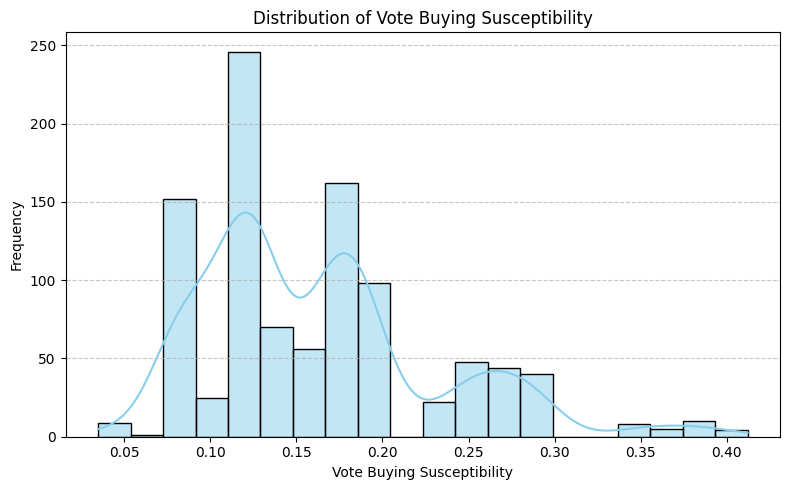


2 out of 5 candidates engaged in vote buying.


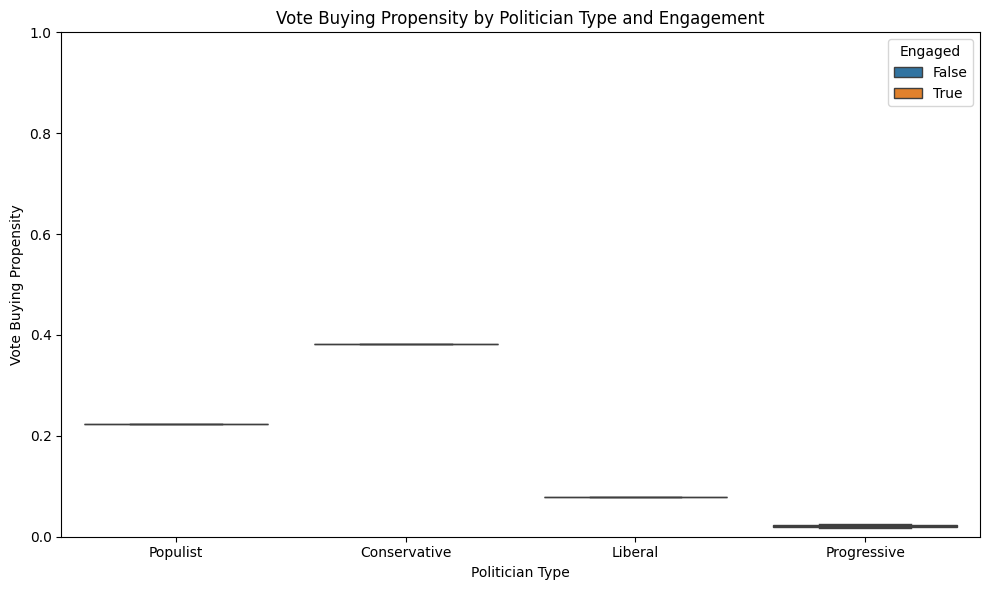

In [15]:
def plot_demographic_distributions(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    demo_data = [{'region': v.region, 'gender': v.gender, 'age_group': v.age_group, 'educ_attainment': v.educ_attainment, 'income_group': v.income_group, 'split': v.split} for v in voters]
    voter_df = pd.DataFrame(demo_data); demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']
    num_plots = len(demographic_columns); ncols = 2; nrows = (num_plots + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows)); axes = axes.flatten()
    fig.suptitle('Distribution of Voter Demographics in Simulation', fontsize=16, y=1.02)
    for i, col in enumerate(demographic_columns):
        ax = axes[i]; order = voter_df[col].value_counts().index
        sns.countplot(data=voter_df, y=col, ax=ax, order=order, palette='viridis'); ax.set_title(f'Distribution by {col.replace("_", " ").title()}'); ax.set_xlabel('Number of Voters'); ax.set_ylabel(col.replace("_", " ").title())
        for container in ax.containers: ax.bar_label(container, fmt='%d', label_type='edge', padding=3)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()

def plot_issue_stance_distributions(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    stance_data = [voter.issue_stances for voter in voters if hasattr(voter, 'issue_stances')]
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data); issues = stance_df.columns; num_issues = len(issues)
    ncols = 2; nrows = (num_issues + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows)); axes = axes.flatten()
    fig.suptitle('Distribution of Voter Issue Stances', fontsize=16, y=1.01)
    for i, issue in enumerate(issues):
        ax = axes[i]; sns.histplot(data=stance_df, x=issue, ax=ax, kde=True, bins=20); ax.set_title(f'Stance on {issue.replace("_", " ").title()}'); ax.set_xlabel('Stance (User Defined 0-1 Scale)'); ax.set_ylabel('Number of Voters'); ax.set_xlim(0, 1)
    for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0.03, 1, 0.99]); plt.show()

def plot_candidate_issue_stances(model):
    # (Keep function as before)
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)];
    if not candidates: print("No candidate agents found."); return
    stance_data = []
    for cand in candidates:
        if hasattr(cand, 'issue_stances'):
            stance_entry = cand.issue_stances.copy(); stance_entry['CandidateID'] = cand.unique_id; stance_entry['Type'] = getattr(cand, 'politician_type', 'Unknown')
            stance_data.append(stance_entry)
    if not stance_data: print("No issue stance data collected."); return
    stance_df = pd.DataFrame(stance_data); stance_df['Label'] = stance_df.apply(lambda row: f"{row['CandidateID']} ({row['Type']})", axis=1); stance_df = stance_df.set_index('Label')
    issue_columns = [col for col in stance_df.columns if col not in ['CandidateID', 'Type']]
    heatmap_data = stance_df[issue_columns].astype(float)
    plt.figure(figsize=(10, 8)); sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5, vmin=0, vmax=1); plt.title('Candidate Issue Stances (User Defined 0-1 Scale)'); plt.xlabel('Issue Area'); plt.ylabel('Candidate (Type)'); plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()

def plot_stances_by_demographic(model, demographic_column, plot_type='box'):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)];
    if not voters: print("No voter agents found."); return
    data_list = []
    for voter in voters:
        if hasattr(voter, 'issue_stances') and hasattr(voter, demographic_column):
            demo_value = getattr(voter, demographic_column)
            for issue, stance in voter.issue_stances.items(): data_list.append({'VoterID': voter.unique_id, demographic_column: demo_value, 'Issue': issue, 'Stance': stance})
    if not data_list: print(f"No stance or demographic data for '{demographic_column}'."); return
    stance_df = pd.DataFrame(data_list); categories = sorted(stance_df[demographic_column].unique())
    if demographic_column == 'age_group':
        age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']; categories = [cat for cat in age_order if cat in categories]
    elif demographic_column == 'income_group':
        income_order = ['poverty', 'low', 'middle', 'high']; categories = [cat for cat in income_order if cat in categories]
    elif demographic_column == 'educ_attainment':
        edu_order = ['no_edu', 'early_child', 'elem', 'hs', 'post_sec', 'short_tert', 'college', 'post_bac']; categories = [cat for cat in edu_order if cat in categories]
    print(f"\nVisualizing Issue Stances by {demographic_column.replace('_', ' ').title()}...")
    plot_kind = plot_type if plot_type in ['box', 'violin'] else 'box'
    g = sns.catplot(data=stance_df, x=demographic_column, y='Stance', col='Issue', kind=plot_kind, col_wrap=3, sharey=True, height=4, aspect=1.2, order=categories, palette='viridis', legend=False)
    g.fig.suptitle(f'Voter Issue Stances by {demographic_column.replace("_", " ").title()}', y=1.03, fontsize=16)
    g.set_axis_labels(demographic_column.replace("_", " ").title(), "Stance (User Defined 0-1 Scale)"); g.set_titles("Issue: {col_name}"); g.set(ylim=(0, 1))
    for ax in g.axes.flatten(): ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def plot_voter_evaluation_scores(model):
    # (Keep function as before)
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]; candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates: print("No voters or candidates found."); return
    plot_data = []; first_choice_scores = defaultdict(list)
    for voter in voters:
        if not voter.ranked_vote: continue
        first_choice_candidate = voter.ranked_vote[0]
        for cand_id, score in voter.approval_scores.items():
            plot_data.append({'CandidateID': cand_id, 'EvaluationScore': score})
            if cand_id == first_choice_candidate.unique_id: first_choice_scores[cand_id].append(score)
    if not plot_data: print("No evaluation scores found."); return
    eval_df = pd.DataFrame(plot_data); avg_first_choice_scores = {cand_id: np.mean(scores) if scores else 0 for cand_id, scores in first_choice_scores.items()}
    avg_plot_data = []; candidate_order = sorted([c.unique_id for c in candidates])
    for cand_id in candidate_order:
         if cand_id in avg_first_choice_scores: avg_plot_data.append({'CandidateID': cand_id, 'AverageScore': avg_first_choice_scores[cand_id]})
    avg_df = pd.DataFrame(avg_plot_data)
    plt.figure(figsize=(14, 7)); sns.boxplot(data=eval_df, x='CandidateID', y='EvaluationScore', order=candidate_order, palette='viridis', showfliers=False)
    if not avg_df.empty: sns.stripplot(data=avg_df, x='CandidateID', y='AverageScore', order=candidate_order, marker='D', s=10, color='red', label='Avg Score from 1st Pref Voters', jitter=False)
    plt.title('Distribution of Voter Evaluation Scores per Candidate'); plt.xlabel('Candidate ID'); plt.ylabel('Issue-Based Evaluation Score (0-1)'); plt.ylim(-0.05, 1.05); plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', linestyle='--', alpha=0.7); plt.legend(loc='best'); plt.tight_layout(); plt.show()

def plot_turnout_by_demographic(model):
    """
    Calculates and plots the voter turnout percentage for various demographic groups
    based on the simulation results.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
               Requires VoterAgents to have demographic attributes and the 'will_vote' attribute.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    if not voters:
        print("No voter agents found in the model.")
        return

    # Check if the turnout simulation has likely run (i.e., will_vote exists)
    # Check the first voter, assuming all voters will have the attribute if one does after step()
    if not hasattr(voters[0], 'will_vote'):
        print("Warning: Voter agents do not have the 'will_vote' attribute.")
        print("Please ensure model.step() has been run before calling this function.")
        return # Return if attribute is missing


    # --- Collect Data ---
    demographic_data = []
    demographic_columns = ['region', 'gender', 'age_group', 'educ_attainment', 'income_group', 'split']

    for voter in voters:
        # Initialize data_entry for each voter
        data_entry = {'will_vote': getattr(voter, 'will_vote', False)} # Default to False if missing
        valid_entry = True
        for col in demographic_columns:
            if hasattr(voter, col):
                data_entry[col] = getattr(voter, col)
            else:
                # Print warning only once per missing attribute type for brevity
                if not hasattr(plot_turnout_by_demographic, f"warned_{col}"):
                     print(f"Warning: At least one voter missing demographic attribute '{col}'. Voters without it will be skipped for this plot.")
                     setattr(plot_turnout_by_demographic, f"warned_{col}", True)
                valid_entry = False
                break # Skip this voter if any demographic is missing
        if valid_entry:
            # Ensure all expected keys are present before appending
            if all(key in data_entry for key in demographic_columns + ['will_vote']):
                 demographic_data.append(data_entry)

    # Reset warnings for next call
    for col in demographic_columns:
         if hasattr(plot_turnout_by_demographic, f"warned_{col}"):
             delattr(plot_turnout_by_demographic, f"warned_{col}")


    if not demographic_data:
        print("No valid voter data with demographics and turnout status found.")
        return

    voter_df = pd.DataFrame(demographic_data)
    # Convert will_vote to integer (1 for True, 0 for False) for mean calculation
    voter_df['will_vote'] = voter_df['will_vote'].astype(int)


    # --- Plotting ---
    print("\nPlotting Simulated Voter Turnout Rate by Demographic Group...")

    num_plots = len(demographic_columns)
    ncols = 2
    nrows = (num_plots + ncols - 1) // ncols # Calculate necessary rows

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() # Flatten the axes array for easy iteration

    fig.suptitle('Simulated Voter Turnout Rate by Demographic Group', fontsize=18, y=1.03)

    for i, col in enumerate(demographic_columns):
        ax = axes[i]

        # Calculate turnout percentage for each category in the demographic column
        # Check if column exists and has data before grouping
        if col not in voter_df.columns or voter_df[col].isnull().all():
             print(f"Skipping plot for '{col}' due to missing data.")
             ax.set_title(f'Turnout by {col.replace("_", " ").title()} (No Data)')
             ax.text(0.5, 0.5, 'No Data Available', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
             continue # Skip to the next plot if no data for this column

        # Ensure the grouping column is treated as categorical for correct grouping
        voter_df[col] = voter_df[col].astype('category')

        turnout_rates = voter_df.groupby(col, observed=False)['will_vote'].mean() * 100 # Use observed=False
        turnout_rates = turnout_rates.sort_values(ascending=False) # Sort for better visualization

        # Define order for specific categorical plots if needed
        order = turnout_rates.index
        # Define known order for specific demographics
        if col == 'age_group':
            age_order = ['<19', '20-29', '30-39', '40-49', '50-59', '60-69', '>70']
            order = pd.Categorical(voter_df[col].unique(), categories=age_order, ordered=True)
            order = order.dropna().sort_values() # Use only categories present in the data, sorted correctly
            # Recalculate turnout rates with the correct order if needed (or pass order to sns.barplot)
            turnout_rates = turnout_rates.reindex(order).dropna()

        elif col == 'income_group':
            income_order = ['below_poverty_line', 'low_income', 'middle_income', 'high_income']
            order = pd.Categorical(voter_df[col].unique(), categories=income_order, ordered=True)
            order = order.dropna().sort_values()
            turnout_rates = turnout_rates.reindex(order).dropna()

        elif col == 'educ_attainment':
            edu_order = ['no_education', 'early_childhood', 'elementary', 'high_school', 'post_secondary', 'short-cycle_tertiary', 'college', 'post_baccalaureate']
            order = pd.Categorical(voter_df[col].unique(), categories=edu_order, ordered=True)
            order = order.dropna().sort_values()
            turnout_rates = turnout_rates.reindex(order).dropna()
        else:
             # For others like region, gender, split, sorted by rate is fine
             order = turnout_rates.index


        # Check if there are any rates to plot after potential filtering/reindexing
        if turnout_rates.empty:
            print(f"Skipping plot for '{col}' as no turnout rates could be calculated.")
            ax.set_title(f'Turnout by {col.replace("_", " ").title()} (No Rates)')
            ax.text(0.5, 0.5, 'No Rates Calculated', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
            continue


        # Create the bar plot
        sns.barplot(x=turnout_rates.index, y=turnout_rates.values, ax=ax, order=order, palette='viridis')

        # Add percentage labels to the bars
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3, fontsize=9)

        # Set titles and labels
        ax.set_title(f'Turnout by {col.replace("_", " ").title()}')
        ax.set_xlabel(col.replace("_", " ").title())
        ax.set_ylabel('Turnout Rate (%)')
        ax.set_ylim(0, 100) # Y-axis from 0% to 100%

        # --- CORRECTED LINE ---
        # Set rotation and alignment for x-tick labels using plt.setp
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Adjust layout to prevent title overlap
    plt.show()

def plot_vote_buying_effect(model):
    """
    Visualizes the change in evaluation scores due to vote buying,
    faceted by candidate vote buying propensity.

    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
               Requires VoterAgents to have 'initial_approval_scores' and 'approval_scores'.
    """
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voters or candidates found.")
        return

    # Check if necessary score attributes exist on the first voter (as a proxy)
    if not hasattr(voters[0], 'initial_approval_scores') or not hasattr(voters[0], 'approval_scores'):
        print("Warning: Score attributes ('initial_approval_scores' or 'approval_scores') not found.")
        print("Ensure VoterAgent.step stores both initial and final scores. Run model.step() first.")
        return

    plot_data = []
    for voter in voters:
        # Ensure scores were calculated for this specific voter
        initial_scores_dict = getattr(voter, 'initial_approval_scores', None)
        final_scores_dict = getattr(voter, 'approval_scores', None)
        if not initial_scores_dict or not final_scores_dict:
            continue # Skip voter if scores are missing

        for cand in candidates:
            cand_id = cand.unique_id
            initial_score = initial_scores_dict.get(cand_id, None)
            final_score = final_scores_dict.get(cand_id, None)
            propensity = getattr(cand, 'vote_buying_propensity', 0.0) # Get candidate propensity

            if initial_score is not None and final_score is not None:
                score_change = final_score - initial_score
                # Include only data points where a score increase occurred
                if score_change > 1e-6: # Use tolerance for floating point comparison
                     plot_data.append({
                         'VoterSusceptibility': getattr(voter, 'vote_buying_susceptibility', 0.0),
                         'CandidatePropensity': propensity,
                         'ScoreChange': score_change
                     })

    if not plot_data:
        print("No score changes due to vote buying were recorded or data is missing.")
        print("(This might be expected if no vote buying offers were accepted in the simulation step)")
        return

    effect_df = pd.DataFrame(plot_data)

    # --- Plotting Score Change Distribution ---
    print("\nPlotting Distribution of Score Changes Due to Vote Buying...")

    # Bin candidate propensity for faceting/hue
    propensity_bins = [-0.01, 0.3, 0.6, 1.0] # Bins: Low(0-0.3], Medium(0.3-0.6], High(0.6-1.0]
    propensity_labels = ['Low Propensity (0-0.3)', 'Medium Propensity (0.3-0.6)', 'High Propensity (0.6-1.0)']
    # Use right=True to include the right edge (e.g., 0.3 is in Low)
    effect_df['PropensityCategory'] = pd.cut(effect_df['CandidatePropensity'],
                                             bins=propensity_bins, labels=propensity_labels,
                                             right=True)

    # Check if any categories ended up empty after filtering score_change > 0
    if effect_df['PropensityCategory'].isnull().all():
        print("Warning: Could not categorize candidate propensities for plotting.")
        # Fallback: Plot without faceting if categorization fails
        plt.figure(figsize=(8, 5))
        sns.histplot(data=effect_df, x='ScoreChange', kde=False, bins=15)
        plt.title('Distribution of Score Increase Due to Vote Buying (All Candidates)')
        plt.xlabel("Score Increase (Final - Initial)")
        plt.ylabel("Number of Occurrences")
    else:
        # Histogram of score changes, faceted by candidate propensity category
        g = sns.displot(data=effect_df, x='ScoreChange', col='PropensityCategory',
                        kind='hist', kde=False, height=4, aspect=1.2, bins=15,
                        col_order=propensity_labels) # Ensure correct order

        g.fig.suptitle('Distribution of Evaluation Score Increase Due to Accepted Vote Buying Offers', y=1.03)
        g.set_axis_labels("Score Increase (Final - Initial)", "Number of Occurrences")
        g.set_titles("Candidate Propensity: {col_name}")

    # Set x-axis limits to focus around 0 and the boost value (e.g., 0.3)
    max_change = effect_df['ScoreChange'].max() if not effect_df.empty else 0.4
    plt.xlim(-0.05, max(0.4, max_change + 0.05)) # Ensure x-axis covers at least 0 to 0.4

    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

def analyze_vote_buying_impact(model):
    """
    Analyze the impact of vote buying on the election results.
    
    Args:
        model: The Mesa ElectionModel instance after model.step() has been run.
    """
    # Extract VoterAgents from the model
    voters = [a for a in model.schedule.agents if isinstance(a, VoterAgent)]
    candidates = [a for a in model.schedule.agents if isinstance(a, CandidateAgent)]
    if not voters or not candidates:
        print("No voter or candidate agents found in the model.")
        return

    # Gather data on vote buying susceptibility
    susceptibility_data = []
    for voter in voters:
        if hasattr(voter, "vote_buying_susceptibility"):
            susceptibility_data.append(voter.vote_buying_susceptibility)

    # Plot distribution of vote buying susceptibility
    plt.figure(figsize=(8, 5))
    sns.histplot(susceptibility_data, kde=True, bins=20, color="skyblue")
    plt.title("Distribution of Vote Buying Susceptibility")
    plt.xlabel("Vote Buying Susceptibility")
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Analyze candidates who engaged in vote buying
    engaged_candidates = [c for c in candidates if getattr(c, 'engaged_in_vote_buying', False)]
    print(f"\n{len(engaged_candidates)} out of {len(candidates)} candidates engaged in vote buying.")

    if engaged_candidates:
        # Prepare data for plotting
        vote_buying_data = []
        for candidate in candidates:
            vote_buying_data.append({
                'CandidateID': candidate.unique_id,
                'Type': candidate.politician_type,
                'Propensity': candidate.vote_buying_propensity,
                'Engaged': getattr(candidate, 'engaged_in_vote_buying', False)
            })
            
        vote_buying_df = pd.DataFrame(vote_buying_data)
        
        # Plot propensity by type with engagement status
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Type', y='Propensity', hue='Engaged', data=vote_buying_df)
        plt.title('Vote Buying Propensity by Politician Type and Engagement')
        plt.xlabel('Politician Type')
        plt.ylabel('Vote Buying Propensity')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

    else:
        print("No candidates engaged in vote buying in this simulation run.")

import matplotlib.pyplot as plt
import seaborn as sns

# Run the model and analyze vote buying impact
model = ElectionModel(num_voters=1000, num_candidates=5)
model.step()
analyze_vote_buying_impact(model)


# Evaluations

## Helper Functions

In [16]:
def calculate_voter_satisfaction(model, winner):
    """
    Calculate the average voter satisfaction for a given winner in the model.
    
    Args:
        model: The ElectionModel instance for the current simulation run.
        winner: The CandidateAgent who won the election.
    
    Returns:
        float: The average satisfaction score of voters who turned out.
    """
    if not winner:
        return None  # No winner, no satisfaction to calculate
    
    voters = [v for v in model.schedule.agents if isinstance(v, VoterAgent) and v.will_vote]
    if not voters:
        return None  # No voters turned out
    
    # Calculate satisfaction for each voter
    satisfaction_scores = [voter.get_issue_score(winner) for voter in voters]
    
    # Return the average satisfaction score
    return np.mean(satisfaction_scores) if satisfaction_scores else None

In [17]:
def calculate_issue_representation_distance(model, winner):
    """
    Calculate the distance between the winner's issue stances and the average voter stance.

    Args:
        model: The ElectionModel instance for the current simulation run.
        winner: The CandidateAgent who won the election.

    Returns:
        float: The weighted Euclidean distance between the winner's stance and the average voter stance.
    """
    if not winner:
        return None  # No winner, no distance to calculate

    voters = [v for v in model.schedule.agents if isinstance(v, VoterAgent)]
    if not voters:
        return None  # No voters in the model

    # Calculate average voter stance and priority
    total_stances = defaultdict(float)
    total_priorities = defaultdict(float)
    total_voters = 0

    for voter in voters:
        if not hasattr(voter, 'issue_stances') or not hasattr(voter, 'issue_priorities'):
            continue  # Skip voters without stances or priorities

        for issue, stance in voter.issue_stances.items():
            total_stances[issue] += stance
        for issue, priority in voter.issue_priorities.items():
            total_priorities[issue] += priority

        total_voters += 1

    if total_voters == 0:
        return None  # No valid voters

    # Compute average stances and priorities
    avg_stances = {issue: total / total_voters for issue, total in total_stances.items()}
    avg_priorities = {issue: total / total_voters for issue, total in total_priorities.items()}

    # Calculate weighted Euclidean distance between winner's stances and average voter stances
    distance = 0.0
    for issue, avg_stance in avg_stances.items():
        winner_stance = winner.issue_stances.get(issue, 0.5)  # Default to neutral stance if missing
        weight = avg_priorities.get(issue, 1.0)  # Default to equal weight if missing
        distance += weight * (winner_stance - avg_stance) ** 2

    return distance ** 0.5  # Return the square root of the sum of squared differences

## Evaluation Functions

Visualizations (10-15) for Vote Buying Insights:

Distribution of Vote Buying Susceptibility among voters (histogram/boxplot).
Vote Buying Propensity by Candidate Type (boxplot/stripplot by archetype and influence factor).
Percentage of Candidates Engaging in Vote Buying vs. influence factor (line/bar plot).
Percentage of Elections Won by Vote Buying Candidates by voting system and influence (multi-line plot).
Stacked Bar: Winners by Politician Type and Vote Buying Status across voting systems and influence.
Agreement Matrix Between Voting Systems (heatmap showing % agreement in winners).
Voter Satisfaction vs. Issue Representation Distance (scatter/trend plot, colored by vote buying engagement).
Average Voter Susceptibility by Influence Factor (line plot with error bars/box elements).
Turnout Rate by Vote Buying Susceptibility (boxplot or grouped bar).
Distribution of Score Increases Due to Vote Buying (histogram, faceted by candidate propensity).
Vote Buying Engagement by Region or Demographic (bar/heatmap).
Vote Buying Offers and Acceptance Rate by candidate type and influence (grouped bar).
Relationship Between Candidate Propensity and Actual Engagement (scatter or violin plot).
Change in Winner Type Distribution as Influence Increases (stacked area/bar plot).
Comparison of Utilitarian Efficiency (Borda Score) for Vote Buying vs. Non-Vote Buying Winners (side-by-side bars).
Calculations (10-15) for Vote Buying Insights:

Mean, Median, and Quartiles of Voter Susceptibility (overall and by demographic).
Proportion of Candidates Engaging in Vote Buying (per influence level and type).
Proportion of Elections Won by Vote Buying Candidates (per voting system and influence).
Average Vote Buying Propensity by Candidate Type (and its standard deviation).
Acceptance Rate of Vote Buying Offers (number accepted / number offered).
Average Score Increase Due to Vote Buying (per candidate and system).
Correlation Between Voter Susceptibility and Acceptance (Pearson/Spearman).
Average Voter Satisfaction for Vote Buying vs. Non-Vote Buying Winners.
Average Issue Representation Distance for Vote Buying vs. Non-Vote Buying Winners.
Frequency of Each Politician Type Winning via Vote Buying (by system/influence).
Agreement Rate Between Voting Systems for Vote Buying Winners.
Average Turnout Rate for High vs. Low Susceptibility Voters.
Proportion of Vote Buying Winners in Each Region/Demographic.
Utilitarian Efficiency (Borda Score) for Vote Buying vs. Non-Vote Buying Winners.
Change in Candidate Engagement Rate as Influence Increases (delta/gradient).


In [18]:
from mesa.batchrunner import batch_run

# Define the parameters for the batch run
parameters = {
    "num_voters": [1000],
    "num_candidates": [4],
    "influence": np.arange(0, 2.5, 0.5),  # Changed from influence_factor to influence
}

# Run batch simulations
results = batch_run(
    ElectionModel,
    parameters=parameters,
    iterations=100,
    max_steps=1,
    data_collection_period=-1,
    display_progress=True,
)

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

  0%|          | 0/500 [00:00<?, ?it/s]

c:\Users\ajalv\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ajalv\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\ajalv\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ajalv\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\ajalv\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\ajalv\AppData

In [19]:
# Print full uncut first 5 rows of the DataFrame
print(results_df.head(5).to_string(index=False))

 RunId  iteration  Step  num_voters  num_candidates  influence  Turnout Percentage Plurality Winner IRV Winner Approval Winner Borda Winner Condorcet Winner                                    Borda Scores  Plurality Satisfaction  IRV Satisfaction  Approval Satisfaction  Borda Satisfaction  Condorcet Satisfaction  Plurality Distance  IRV Distance  Approval Distance  Borda Distance  Condorcet Distance  Avg Vote Buying Susceptibility                                                                                                                                                                                                                                                                     Avg Voter Issue Stances                                                                                                                                                                                                                                                                 Avg Candidate Issue Stanc

In [20]:
# Save the results to a CSV file
results_df.to_csv("batch_simulation_results_vote_buying_only.csv", index=False)

In [21]:
print("\n=== Simulation Results ===")
print(f"Total Runs: {len(results_df)}")
print(f"Average Turnout Rate: {results_df['Turnout Percentage'].mean():.2f}%")
    
# Updated Results Analysis with optimizations
print("\n=== Winner Frequency Analysis ===")

# Prepare data for analysis
methods = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']

# Get a reference to all candidates from the model
candidates = {c.unique_id: c for c in model.schedule.agents if isinstance(c, CandidateAgent)}

# Analyze each voting method
for method in methods:
    col = f'{method} Winner'
    if col in results_df.columns and not results_df[col].isna().all():
        print(f"\n{method.upper()} WINNERS BY CHARACTERISTICS:")
        
        # Create a Series of winner IDs excluding NaN values
        winners = results_df[col].dropna()
        total_winners = len(winners)
        
        if total_winners == 0:
            print(f"  No {method} winners found in the data.")
            continue
            
        # Calculate vote buying statistics
        vote_buying_stats = winners.apply(lambda winner_id: 
            candidates.get(winner_id).engaged_in_vote_buying 
            if winner_id in candidates else False
        ).value_counts(normalize=True) * 100
        
        print(f"  Engaged in Vote Buying: {vote_buying_stats.get(True, 0):.1f}%")
        print(f"  Did Not Vote Buy: {vote_buying_stats.get(False, 0):.1f}%")
        
        # Calculate politician type statistics
        type_stats = winners.apply(lambda winner_id: 
            candidates.get(winner_id).politician_type if winner_id in candidates else "Unknown"
        ).value_counts(normalize=True) * 100
        
        # Display type percentages
        for pol_type, pct in type_stats.items():
            print(f"  {pol_type}: {pct:.1f}%")


=== Simulation Results ===
Total Runs: 502000
Average Turnout Rate: 83.38%

=== Winner Frequency Analysis ===

PLURALITY WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 53.2%
  Did Not Vote Buy: 46.8%
  Populist: 38.4%
  Liberal: 38.2%
  Conservative: 14.8%
  Progressive: 8.6%

IRV WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 43.2%
  Did Not Vote Buy: 56.8%
  Liberal: 47.8%
  Populist: 35.4%
  Progressive: 9.0%
  Conservative: 7.8%

APPROVAL WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 38.8%
  Did Not Vote Buy: 61.2%
  Liberal: 53.6%
  Populist: 31.4%
  Progressive: 7.6%
  Conservative: 7.4%

BORDA WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 39.8%
  Did Not Vote Buy: 60.2%
  Liberal: 52.6%
  Populist: 34.6%
  Progressive: 7.6%
  Conservative: 5.2%

CONDORCET WINNERS BY CHARACTERISTICS:
  Engaged in Vote Buying: 42.8%
  Did Not Vote Buy: 57.2%
  Liberal: 49.2%
  Populist: 37.0%
  Progressive: 8.0%
  Conservative: 5.8%


In [22]:
def calculate_winner_agreement(results_df):
    """
    Calculate how often different pairs of voting systems produce the same winner.

    Args:
        results_df (pd.DataFrame): DataFrame containing the results of the simulation runs.

    Returns:
        pd.DataFrame: A DataFrame showing the agreement percentages for each pair of voting systems.
    """
    methods = ['Plurality Winner', 'IRV Winner', 'Approval Winner', 'Borda Winner', 'Condorcet Winner']
    agreement_counts = {}

    # Iterate through all pairs of methods
    for i, method1 in enumerate(methods):
        for method2 in methods[i + 1:]:
            # Count how often the winners match
            matches = (results_df[method1] == results_df[method2]).sum()
            total_runs = len(results_df)
            agreement_percentage = (matches / total_runs) * 100
            agreement_counts[(method1, method2)] = agreement_percentage

    # Convert to a DataFrame for better visualization
    agreement_df = pd.DataFrame([
        {'Method 1': m1, 'Method 2': m2, 'Agreement (%)': agreement_counts[(m1, m2)]}
        for m1, m2 in agreement_counts
    ])

    return agreement_df

# Perform the analysis
agreement_df = calculate_winner_agreement(results_df)

# Display the results
print("\n=== Winner Agreement Analysis ===")
print(agreement_df)


=== Winner Agreement Analysis ===
           Method 1          Method 2  Agreement (%)
0  Plurality Winner        IRV Winner           82.0
1  Plurality Winner   Approval Winner           71.4
2  Plurality Winner      Borda Winner           78.0
3  Plurality Winner  Condorcet Winner           79.6
4        IRV Winner   Approval Winner           79.6
5        IRV Winner      Borda Winner           89.4
6        IRV Winner  Condorcet Winner           94.2
7   Approval Winner      Borda Winner           83.2
8   Approval Winner  Condorcet Winner           83.0
9      Borda Winner  Condorcet Winner           93.0


In [23]:
import ast

def analyze_utilitarian_efficiency(results_df):
    """
    Analyze the average Borda score of the winners for each voting system.
    Optimized using pandas and NumPy features for better performance.
    """
    methods = ['Plurality Winner', 'IRV Winner', 'Approval Winner', 'Borda Winner', 'Condorcet Winner']
    efficiency_results = {}
    
    # First convert string representations of Borda scores to actual dictionaries
    # This avoids repeatedly parsing the same strings in the loop
    if isinstance(results_df['Borda Scores'].iloc[0], str):
        results_df['Borda_Scores_Dict'] = results_df['Borda Scores'].apply(ast.literal_eval)
    else:
        results_df['Borda_Scores_Dict'] = results_df['Borda Scores']
    
    # Process each voting method
    for method in methods:
        # Create a Series of winner IDs and their corresponding Borda scores
        winner_scores = results_df.apply(
            lambda row: row['Borda_Scores_Dict'].get(row[method], 0) 
            if pd.notna(row[method]) and isinstance(row['Borda_Scores_Dict'], dict) 
            else np.nan, 
            axis=1
        )
        
        # Calculate the mean, handling NaN values
        avg_score = winner_scores.mean()
        efficiency_results[method] = avg_score
    
    return efficiency_results

# Perform the analysis
efficiency_results = analyze_utilitarian_efficiency(results_df)

# Display the results
print("\n=== Utilitarian Efficiency Analysis ===")
for method, avg_borda_score in efficiency_results.items():
    method_name = method.replace('Winner', '').strip()
    if pd.notna(avg_borda_score):
        print(f"{method_name}: Average Borda Score = {avg_borda_score:.2f}")
    else:
        print(f"{method_name}: No Data")


=== Utilitarian Efficiency Analysis ===
Plurality: Average Borda Score = 1588.25
IRV: Average Borda Score = 1604.04
Approval: Average Borda Score = 1597.23
Borda: Average Borda Score = 1610.58
Condorcet: Average Borda Score = 1607.98


In [24]:
# Calculate overall average satisfaction for each voting system
print("\n=== Issue Representation (Average Voter Satisfaction) ===")
satisfaction_columns = [
    'Plurality Satisfaction',
    'IRV Satisfaction',
    'Approval Satisfaction',
    'Borda Satisfaction',
    'Condorcet Satisfaction',
]

for col in satisfaction_columns:
    avg_satisfaction = results_df[col].mean()
    print(f"{col.replace('_satisfaction', '').title()} Winner: Average Satisfaction = {avg_satisfaction:.4f}")


=== Issue Representation (Average Voter Satisfaction) ===
Plurality Satisfaction Winner: Average Satisfaction = 0.6998
Irv Satisfaction Winner: Average Satisfaction = 0.7023
Approval Satisfaction Winner: Average Satisfaction = 0.7032
Borda Satisfaction Winner: Average Satisfaction = 0.7031
Condorcet Satisfaction Winner: Average Satisfaction = 0.7029


In [25]:
print("\n=== Issue Representation Distance Analysis ===")
distance_columns = [
    'Plurality Distance',
    'IRV Distance',
    'Approval Distance',
    'Borda Distance',
    'Condorcet Distance',
]

for col in distance_columns:
    avg_distance = results_df[col].mean()
    print(f"{col.replace('_distance', '').title()} Winner: Average Distance = {avg_distance:.4f}")


=== Issue Representation Distance Analysis ===
Plurality Distance Winner: Average Distance = 0.2879
Irv Distance Winner: Average Distance = 0.2854
Approval Distance Winner: Average Distance = 0.2843
Borda Distance Winner: Average Distance = 0.2849
Condorcet Distance Winner: Average Distance = 0.2849


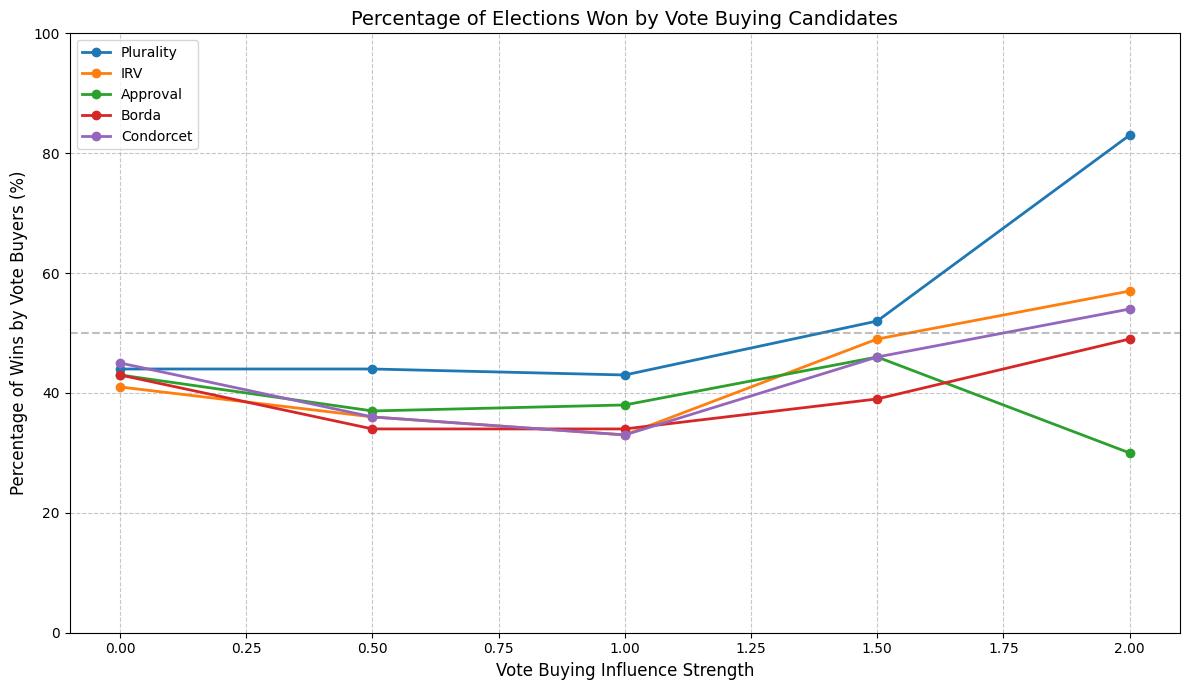

<Figure size 1200x700 with 0 Axes>

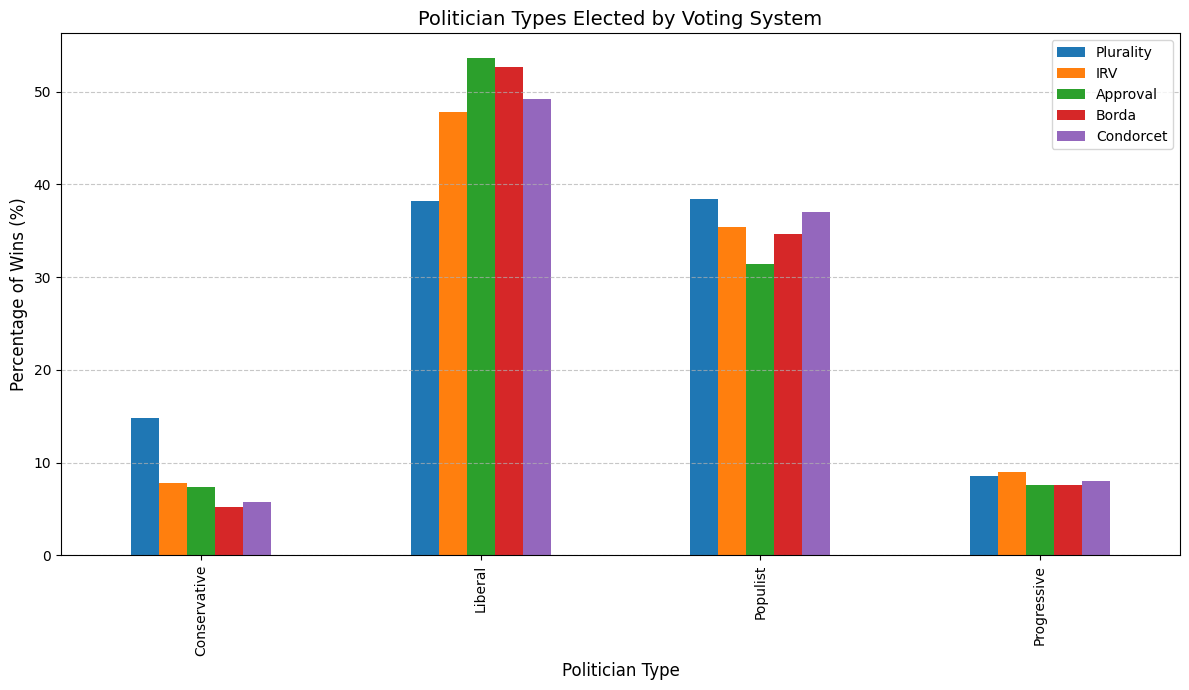

In [26]:
import pandas as pd
import numpy as np

# Plot relationship between vote buying influence and winner characteristics
import matplotlib.pyplot as plt

# First, create a lookup dictionary for candidates to avoid repeated searches
candidate_lookup = {}

# Build a more efficient lookup dictionary keyed by candidate ID
for agent in model.schedule.agents:
    if isinstance(agent, CandidateAgent):
        candidate_lookup[agent.unique_id] = {
            'engaged_in_vote_buying': getattr(agent, 'engaged_in_vote_buying', False),
            'politician_type': getattr(agent, 'politician_type', 'Unknown')
        }

# Group by influence and calculate percentages more efficiently
methods = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
results = []

# Process each influence level
for influence_level, group in results_df.groupby('influence'):
    row_data = {'influence': influence_level, 'runs': len(group)}
    
    # Process each voting method
    for method in methods:
        winner_col = f'{method} Winner'
        if winner_col not in group.columns:
            continue
            
        # Count winners who engaged in vote buying
        winners = group[winner_col].dropna()
        vote_buyers = sum(candidate_lookup.get(winner_id, {}).get('engaged_in_vote_buying', False) 
                         for winner_id in winners)
        
        # Store raw counts and percentages
        row_data[f'vote_buyers_won_{method.lower()}'] = vote_buyers
        row_data[f'{method.lower()}_pct'] = (vote_buyers / len(winners)) * 100 if len(winners) > 0 else 0
        
    results.append(row_data)

# Create dataframe from results
vote_buying_analysis = pd.DataFrame(results)

# Plot the results
plt.figure(figsize=(12, 7))

for method in methods:
    method_lower = method.lower()
    pct_col = f'{method_lower}_pct'
    
    if pct_col in vote_buying_analysis.columns:
        plt.plot(
            vote_buying_analysis['influence'], 
            vote_buying_analysis[pct_col], 
            marker='o', 
            linewidth=2, 
            label=method
        )

plt.title('Percentage of Elections Won by Vote Buying Candidates', fontsize=14)
plt.xlabel('Vote Buying Influence Strength', fontsize=12)
plt.ylabel('Percentage of Wins by Vote Buyers (%)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 100)  # Set y-axis from 0 to 100%
plt.axhline(y=50, color='gray', linestyle='--', alpha=0.5)  # Add reference line at 50%
plt.tight_layout()
plt.show()

# Also add a separate analysis of politician types winning by voting system
plt.figure(figsize=(12, 7))

# Count winners by politician type for each system
type_counts = {}

for method in methods:
    winner_col = f'{method} Winner'
    if winner_col in results_df.columns:
        # Group winners by politician type
        type_distrib = results_df[winner_col].apply(
            lambda w: candidate_lookup.get(w, {}).get('politician_type', 'Unknown')
        ).value_counts(normalize=True) * 100
        
        type_counts[method] = type_distrib

# Convert to DataFrame for easier plotting
politician_type_df = pd.DataFrame(type_counts).fillna(0)

# Create stacked bar chart
politician_type_df.plot(kind='bar', stacked=False, figsize=(12, 7))
plt.title('Politician Types Elected by Voting System', fontsize=14)
plt.xlabel('Politician Type', fontsize=12)
plt.ylabel('Percentage of Wins (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\ajalv\AppData\Local\Temp\ipykernel_16408\2198522386.py:71: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot(x, influence_df['Pct_Engaged'], 'k--', marker='o', linewidth=2,


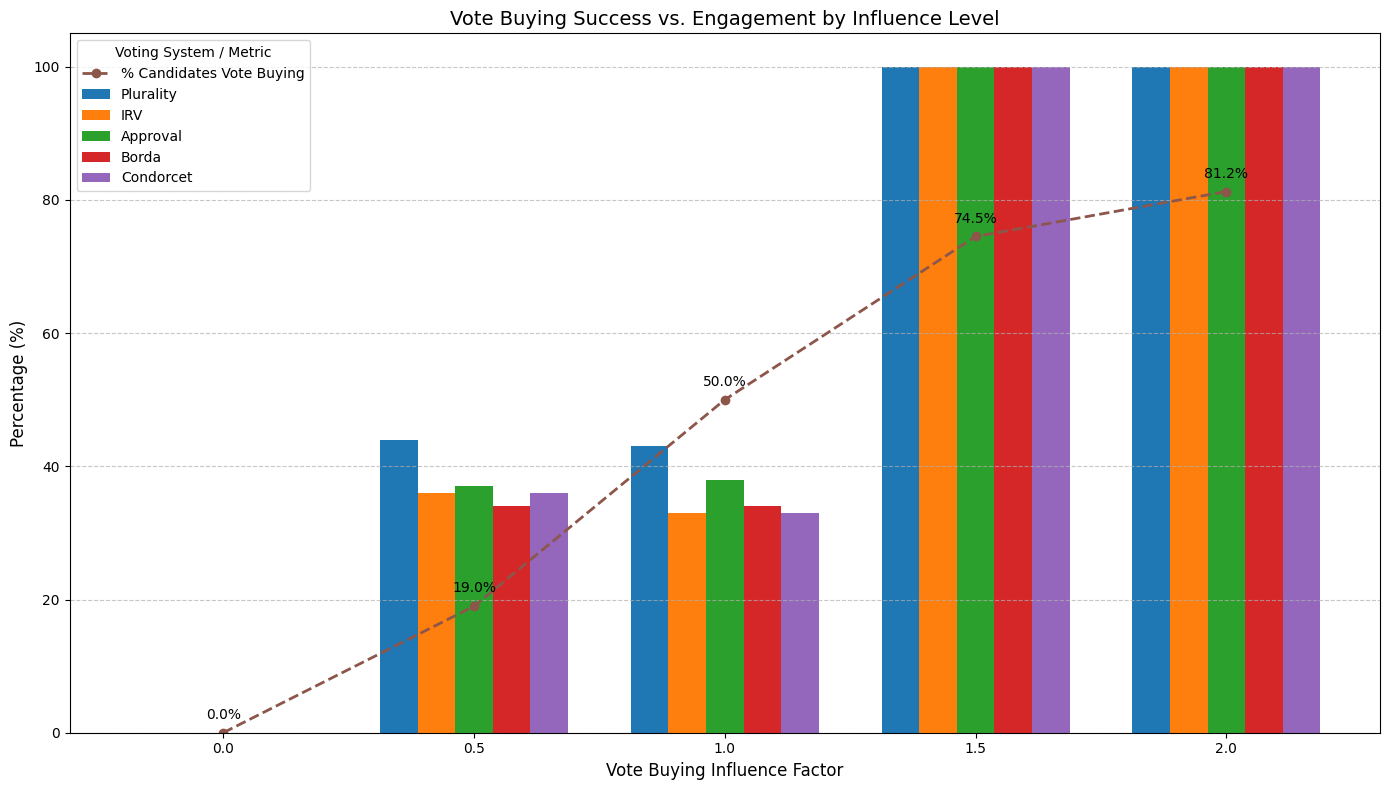

In [27]:
# Create a visualization showing the relationship between influence strength
# and vote buying effectiveness across different metrics

# First, prepare the data by grouping by influence level
influence_analysis = []

for influence_level, group in results_df.groupby('influence'):
    # Get candidates who engaged in vote buying
    engaged_candidates = group[
        (group['AgentType'] == 'Candidate') & 
        (group['Candidate Engaged in Vote Buying'] == True)
    ]
    
    # Count total candidates and those who engaged in vote buying
    total_candidates = len(group[group['AgentType'] == 'Candidate'])
    engaged_count = len(engaged_candidates)
    
    # Calculate percentage of candidates who engaged in vote buying
    pct_engaged = (engaged_count / total_candidates * 100) if total_candidates > 0 else 0
    
    # Count wins across voting systems by vote buying candidates
    wins_by_vote_buyers = {
        'Plurality': 0,
        'IRV': 0,
        'Approval': 0,
        'Borda': 0,
        'Condorcet': 0
    }
    
    # Get list of candidates who engaged in vote buying
    vote_buyer_ids = engaged_candidates['AgentID'].tolist()
    
    # Count wins for each voting system
    for system in wins_by_vote_buyers.keys():
        winner_col = f'{system} Winner'
        if winner_col in group.columns:
            wins_by_vote_buyers[system] = sum(group[winner_col].isin(vote_buyer_ids))
            
    # Calculate average voter susceptibility for this influence level
    avg_susceptibility = group['Avg Vote Buying Susceptibility'].mean()
    
    # Add to results
    influence_analysis.append({
        'Influence': influence_level,
        'Pct_Engaged': pct_engaged,
        'Avg_Susceptibility': avg_susceptibility,
        **{f'{system}_Wins': wins_by_vote_buyers[system] for system in wins_by_vote_buyers},
        **{f'{system}_Win_Pct': (wins_by_vote_buyers[system] / len(group) * 100) 
           if len(group) > 0 else 0 for system in wins_by_vote_buyers}
    })
    
# Convert to DataFrame
influence_df = pd.DataFrame(influence_analysis)

# Create a grouped bar chart comparing voting systems
plt.figure(figsize=(14, 8))

# Get influence levels and set bar positions
influence_levels = influence_df['Influence']
x = np.arange(len(influence_levels))
width = 0.15

# Plot bars for each voting system
plt.bar(x - width*2, influence_df['Plurality_Win_Pct'], width, label='Plurality', color='#1f77b4')
plt.bar(x - width, influence_df['IRV_Win_Pct'], width, label='IRV', color='#ff7f0e')
plt.bar(x, influence_df['Approval_Win_Pct'], width, label='Approval', color='#2ca02c')
plt.bar(x + width, influence_df['Borda_Win_Pct'], width, label='Borda', color='#d62728')
plt.bar(x + width*2, influence_df['Condorcet_Win_Pct'], width, label='Condorcet', color='#9467bd')

# Plot the percentage of candidates who engaged in vote buying as a line
plt.plot(x, influence_df['Pct_Engaged'], 'k--', marker='o', linewidth=2, 
         label='% Candidates Vote Buying', color='#8c564b')

# Add title and labels
plt.title('Vote Buying Success vs. Engagement by Influence Level', fontsize=14)
plt.xlabel('Vote Buying Influence Factor', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(x, influence_levels)
plt.legend(title='Voting System / Metric')

# Add grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with values for better readability
for i, inf in enumerate(influence_levels):
    # Add percentage label for engagement line
    plt.annotate(f"{influence_df['Pct_Engaged'].iloc[i]:.1f}%", 
                 (i, influence_df['Pct_Engaged'].iloc[i]),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center')

plt.tight_layout()
plt.show()

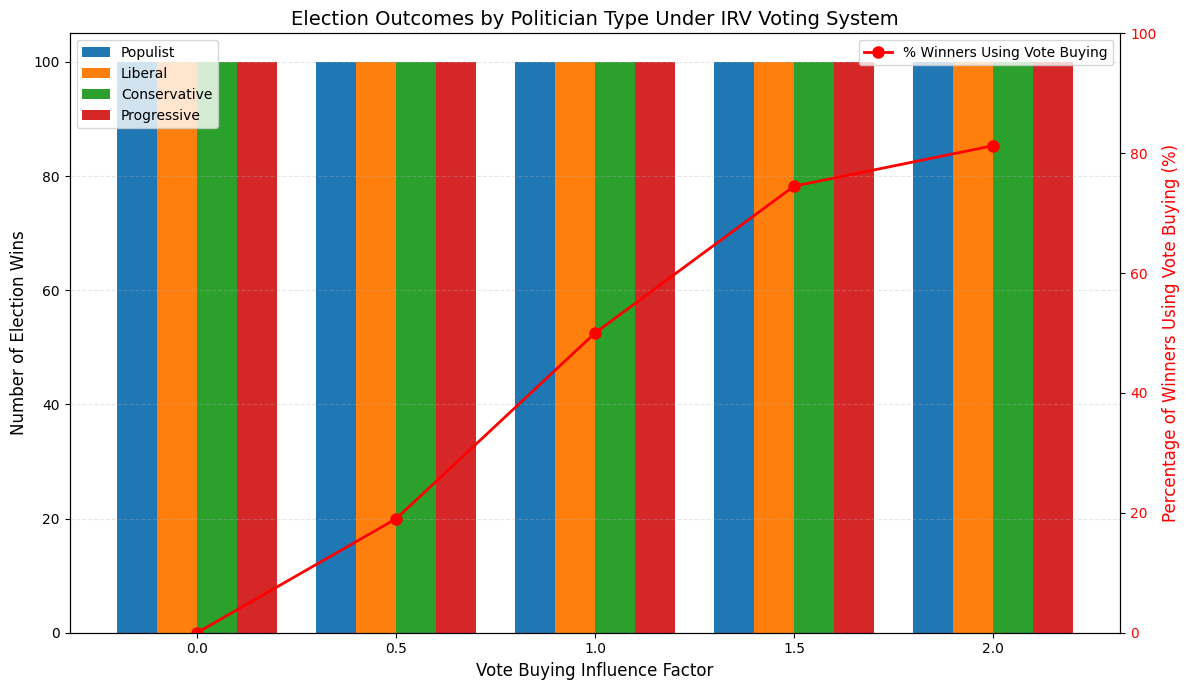

In [28]:
def plot_winners_by_type_and_vote_buying(voting_system = 'Plurality'):
    """
    Create a visualization showing how vote buying influence affects winners 
    across different politician types with vote buying percentage as a line.
    """
    # Define constants
    # We'll focus on one voting system for clarity
    pol_types = ['Populist', 'Liberal', 'Conservative', 'Progressive']
    
    # Prepare data structures
    win_counts = []
    vb_percentages = []
    
    # Get unique influence levels
    influence_levels = sorted(results_df['influence'].unique())
    
    # Process data for each influence level
    for influence in influence_levels:
        # Filter data for this influence level
        group = results_df[results_df['influence'] == influence]
        candidates = group[group['AgentType'] == 'Candidate']
        
        # Get winners for the selected voting system
        winner_column = f'{voting_system} Winner'
        if winner_column not in group.columns:
            continue
            
        winners = group[~group[winner_column].isna()][winner_column].values
        
        if len(winners) == 0:
            continue
            
        # Count wins by politician type
        win_data = {}
        for pol_type in pol_types:
            # Find winners of this type
            pol_winners = candidates[
                (candidates['AgentID'].isin(winners)) & 
                (candidates['Candidate Type'] == pol_type)
            ]
            win_data[pol_type] = len(pol_winners)
        
        # Calculate percentage of winners who engaged in vote buying
        winners_data = candidates[candidates['AgentID'].isin(winners)]
        total_winners = len(winners_data)
        vb_winners = len(winners_data[winners_data['Candidate Engaged in Vote Buying'] == True])
        vb_percentage = (vb_winners / total_winners * 100) if total_winners > 0 else 0
        
        # Store results
        win_counts.append(win_data)
        vb_percentages.append(vb_percentage)
    
    # Create figure
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    # Set up bar positions
    x = np.arange(len(influence_levels))
    width = 0.2
    
    # Plot bars for each politician type
    for i, pol_type in enumerate(pol_types):
        counts = [data[pol_type] for data in win_counts]
        position = x + (i - 1.5) * width
        ax1.bar(position, counts, width, label=pol_type)
    
    # Configure the primary y-axis (bar chart)
    ax1.set_xlabel('Vote Buying Influence Factor', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(influence_levels)
    ax1.set_ylabel('Number of Election Wins', fontsize=12)
    ax1.set_title(f'Election Outcomes by Politician Type Under {voting_system} Voting System', fontsize=14)
    ax1.legend(loc='upper left')
    
    # Create secondary y-axis for vote buying percentage (line graph)
    ax2 = ax1.twinx()
    ax2.plot(x, vb_percentages, 'r-', marker='o', linewidth=2, markersize=8, 
             label='% Winners Using Vote Buying')
    ax2.set_ylabel('Percentage of Winners Using Vote Buying (%)', color='red', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 100)
    ax2.grid(False)
    ax2.legend(loc='upper right')
    
    # Add grid for readability
    ax1.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    return fig

# Execute the visualization
fig = plot_winners_by_type_and_vote_buying("IRV")
plt.show()


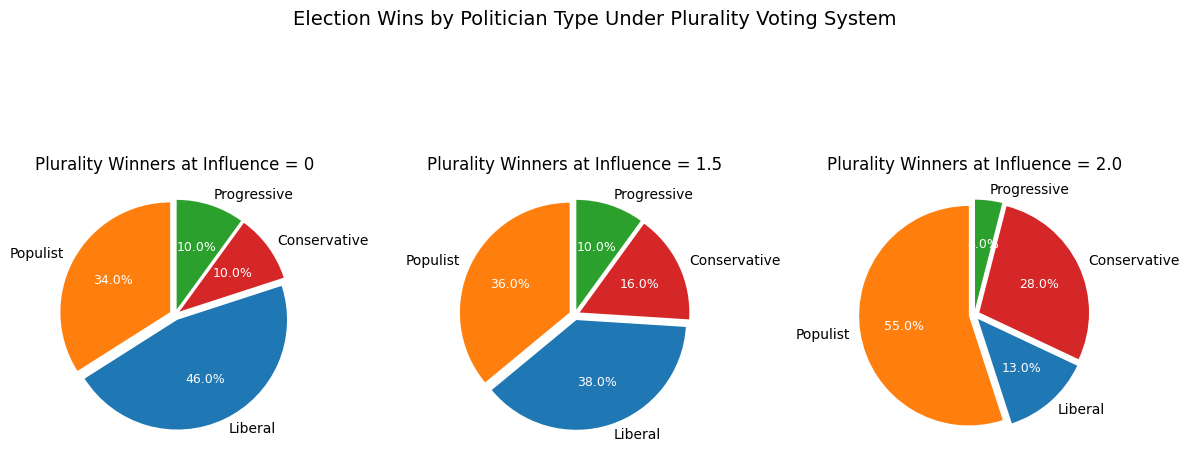

In [29]:
def plot_wins_by_politician_type(influence_levels=[0, 2.0], voting_system='IRV'):
    """
    Create pie charts showing the proportion of election wins by politician type
    at specified influence levels for a selected voting system.
    
    Parameters:
    -----------
    influence_levels : list
        List of influence levels to compare (default: [0, 2.0])
    voting_system : str
        Voting system to analyze (default: 'IRV')
    """
    # Ensure the voting system is valid
    winner_column = f'{voting_system} Winner'
    if winner_column not in results_df.columns:
        print(f"Error: '{winner_column}' not found in results data.")
        return
    
    # Set up the plot
    fig, axes = plt.subplots(1, len(influence_levels), figsize=(12, 6))
    if not isinstance(axes, np.ndarray):
        axes = [axes]  # Ensure axes is always a list
    
    # Define a consistent color palette for politician types
    colors = {
        'Populist': '#ff7f0e',      # Orange
        'Liberal': '#1f77b4',       # Blue
        'Conservative': '#d62728',  # Red
        'Progressive': '#2ca02c'    # Green
    }
    
    politician_types = list(colors.keys())
    
    # Process each influence level
    for i, influence in enumerate(influence_levels):
        # Filter data for this influence level
        influence_data = results_df[results_df['influence'] == influence]
        
        if influence_data.empty:
            axes[i].text(0.5, 0.5, f"No data for influence={influence}", 
                        ha='center', va='center')
            axes[i].set_title(f"Influence = {influence}")
            continue
        
        # Get the winners for the selected voting system
        winners = influence_data[winner_column].dropna().tolist()
        
        if not winners:
            axes[i].text(0.5, 0.5, f"No winners found for {voting_system}", 
                        ha='center', va='center')
            axes[i].set_title(f"Influence = {influence}")
            continue
        
        # Create a mapping from agent ID to politician type for faster lookups
        winner_type_map = dict(zip(
            influence_data[influence_data['AgentType'] == 'Candidate']['AgentID'],
            influence_data[influence_data['AgentType'] == 'Candidate']['Candidate Type']
        ))
        
        # Count winners by politician type
        type_counts = {pol_type: 0 for pol_type in politician_types}
        for winner_id in winners:
            if winner_id in winner_type_map:
                type_counts[winner_type_map[winner_id]] += 1
        
        # Only include types that have at least one win
        type_counts = {k: v for k, v in type_counts.items() if v > 0}
        
        # Create the pie chart
        wedges, texts, autotexts = axes[i].pie(
            list(type_counts.values()), 
            labels=list(type_counts.keys()),
            autopct='%1.1f%%',
            colors=[colors.get(t, 'gray') for t in type_counts.keys()],
            startangle=90,
            explode=[0.05] * len(type_counts)  # Slight explosion for visibility
        )
        
        # Styling
        for text in texts:
            text.set_fontsize(10)
        for autotext in autotexts:
            autotext.set_fontsize(9)
            autotext.set_color('white')
        
        axes[i].set_title(f"{voting_system} Winners at Influence = {influence}")
    
    # Overall title
    fig.suptitle(f'Election Wins by Politician Type Under {voting_system} Voting System', 
                fontsize=14, y=0.98)
    
    plt.tight_layout()
    return fig

# Execute the visualization
fig = plot_wins_by_politician_type([0, 1.5, 2.0], 'Plurality')
plt.show()

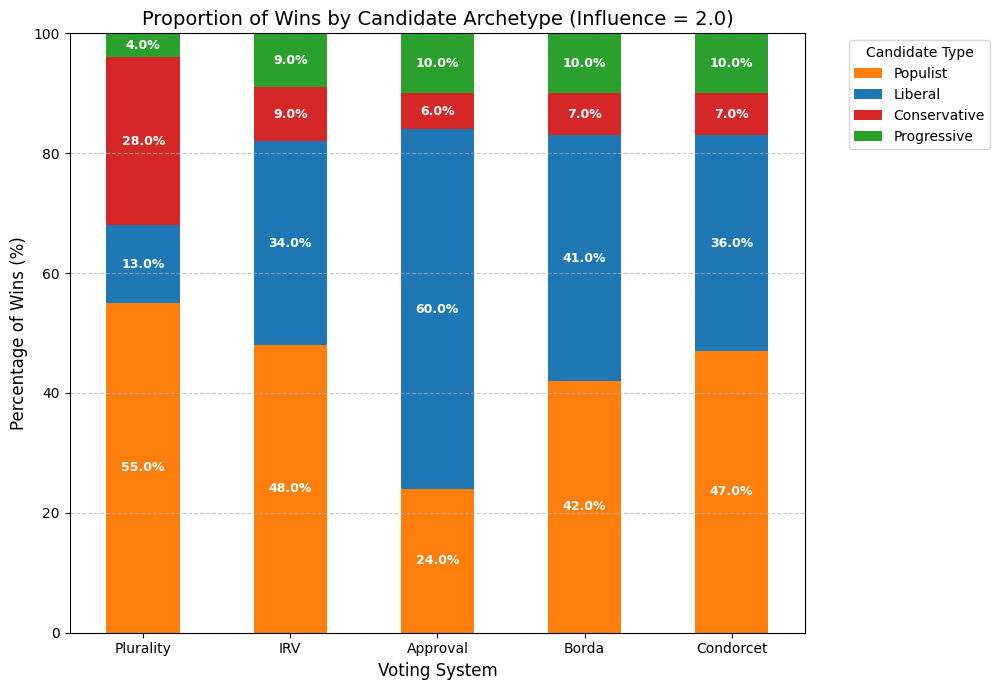

In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

def plot_winner_proportions_at_influence(influence_level=1.0):
    """
    Creates a stacked bar chart showing the proportion of each candidate archetype 
    that won for each voting system at a specific influence level.

    Args:
        influence_level (float): The influence level to filter the results for.
    """
    
    # Filter results for the specified influence level
    filtered_df = results_df[results_df['influence'] == influence_level].copy()

    if filtered_df.empty:
        print(f"No data found for influence level {influence_level}.")
        return

    # Extract candidate information (ID and Type) from the filtered data
    # Ensure we get unique candidate info per run if necessary, but usually it's consistent
    candidate_info = filtered_df[filtered_df['AgentType'] == 'Candidate'][['RunId', 'AgentID', 'Candidate Type']].drop_duplicates(subset=['RunId', 'AgentID'])
    
    # Create a lookup dictionary mapping AgentID to Candidate Type for this influence level
    # We might need to handle cases where a candidate ID appears in multiple runs (should be the same type)
    candidate_type_lookup = candidate_info.set_index('AgentID')['Candidate Type'].to_dict()

    methods = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
    politician_types = ['Populist', 'Liberal', 'Conservative', 'Progressive']
    proportions_data = {method: {ptype: 0 for ptype in politician_types} for method in methods}
    total_wins_per_method = {method: 0 for method in methods}

    # Calculate win counts for each type per method
    for method in methods:
        winner_col = f'{method} Winner'
        if winner_col not in filtered_df.columns:
            print(f"Warning: Column '{winner_col}' not found.")
            continue

        # Get non-null winner IDs for this method
        winners = filtered_df[winner_col].dropna()
        total_wins_per_method[method] = len(winners)

        if total_wins_per_method[method] == 0:
            continue

        # Count wins by type using the lookup
        for winner_id in winners:
            winner_type = candidate_type_lookup.get(winner_id)
            if winner_type in proportions_data[method]:
                proportions_data[method][winner_type] += 1

    # Convert counts to proportions
    proportions_df_data = {}
    for method, type_counts in proportions_data.items():
        total_wins = total_wins_per_method[method]
        if total_wins > 0:
            proportions_df_data[method] = {ptype: (count / total_wins) * 100 for ptype, count in type_counts.items()}
        else:
            proportions_df_data[method] = {ptype: 0 for ptype in politician_types} # Handle case with no wins

    # Create DataFrame suitable for plotting
    proportions_df = pd.DataFrame(proportions_df_data).T # Transpose to have methods as rows

    # Define colors for consistency
    colors = {
        'Populist': '#ff7f0e',      # Orange
        'Liberal': '#1f77b4',       # Blue
        'Conservative': '#d62728',  # Red
        'Progressive': '#2ca02c'    # Green
    }
    
    # Ensure columns are in the desired order and use defined colors
    plot_order = [ptype for ptype in politician_types if ptype in proportions_df.columns]
    color_list = [colors.get(ptype, '#808080') for ptype in plot_order] # Use gray for unexpected types

    # Create the stacked bar chart
    ax = proportions_df[plot_order].plot(kind='bar', stacked=True, figsize=(12, 7), color=color_list)

    # Customize the plot
    plt.title(f'Proportion of Wins by Candidate Archetype (Influence = {influence_level})', fontsize=14)
    plt.xlabel('Voting System', fontsize=12)
    plt.ylabel('Percentage of Wins (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.ylim(0, 100)
    plt.legend(title='Candidate Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add percentage labels to the bars
    for container in ax.containers:
        # Filter out labels for zero-height bars
        labels = [f'{v:.1f}%' if v > 0 else '' for v in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='white', weight='bold')

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
    plt.show()

# Run the function for influence level 1.0
plot_winner_proportions_at_influence(influence_level=2.0)

In [31]:
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

# 1. Vote Buying Impact on Election Outcomes by Voting System
def plot_vote_buying_impact():
    # Use the existing vote_buying_analysis dataframe directly
    plt.figure(figsize=(10, 6))
    
    # Define systems and their display labels
    systems = ['plurality', 'irv', 'approval', 'borda', 'condorcet']
    labels = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
    
    # Plot each system's data
    for system, label in zip(systems, labels):
        plt.plot(vote_buying_analysis['influence'], 
                 vote_buying_analysis[f'{system}_pct'], 
                 marker='o', linewidth=2, label=label)
    
    # Add plot details
    plt.title('Vote Buying Impact on Election Winners by System', fontsize=14)
    plt.xlabel('Vote Buying Influence Factor', fontsize=12)
    plt.ylabel('% Elections Won by Vote Buyers', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    return plt

# 2. Agreement Matrix Between Voting Systems
def plot_voting_system_agreement():
    # Calculate agreement percentages more efficiently
    systems = ['Plurality Winner', 'IRV Winner', 'Approval Winner', 'Borda Winner', 'Condorcet Winner']
    labels = [s.replace(' Winner', '') for s in systems]
    
    # Create agreement matrix using vectorized operations
    agreement_matrix = np.zeros((len(systems), len(systems)))
    for i, sys1 in enumerate(systems):
        for j, sys2 in enumerate(systems):
            if i == j:
                agreement_matrix[i, j] = 100  # Same system always agrees with itself
            else:
                agreement_matrix[i, j] = 100 * np.mean(results_df[sys1] == results_df[sys2])
    
    # Plot
    fig, ax = plt.subplots(figsize=(9, 8))
    
    # Use a diverging colormap
    cmap = LinearSegmentedColormap.from_list('custom_cmap', 
                                            ['#d73027', '#f46d43', '#fdae61', '#fee090', 
                                             '#e0f3f8', '#abd9e9', '#74add1', '#4575b4'], N=256)
    
    im = ax.imshow(agreement_matrix, cmap=cmap, vmin=0, vmax=100)
    
    # Add text annotations
    for i in range(len(systems)):
        for j in range(len(systems)):
            color = "black" if 30 < agreement_matrix[i, j] < 70 else "white"
            ax.text(j, i, f"{agreement_matrix[i, j]:.1f}%", ha="center", va="center", 
                   color=color, fontweight='bold')
    
    # Customize
    plt.colorbar(im, label='Agreement Percentage (%)')
    ax.set_xticks(np.arange(len(systems)))
    ax.set_yticks(np.arange(len(systems)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    ax.set_title('Agreement Between Different Voting Systems (%)', fontsize=14)
    plt.tight_layout()
    return plt

# 3. Voter Satisfaction vs. Issue Distance by Voting System
def plot_satisfaction_vs_distance():
    # Use more efficient data preparation with pandas
    systems = ['Plurality', 'IRV', 'Approval', 'Borda', 'Condorcet']
    
    # Prepare data more efficiently
    plot_data = []
    for system in systems:
        system_data = results_df[['influence', f'{system} Satisfaction', f'{system} Distance']].copy()
        system_data['System'] = system
        system_data.rename(columns={
            f'{system} Satisfaction': 'Satisfaction', 
            f'{system} Distance': 'Distance'
        }, inplace=True)
        plot_data.append(system_data)
    
    plot_df = pd.concat(plot_data)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = sns.color_palette('Set1', n_colors=len(systems))
    markers = ['o', 's', '^', 'D', 'X']
    
    for i, system in enumerate(systems):
        data = plot_df[plot_df['System'] == system]
        ax.scatter(data['Distance'], data['Satisfaction'], c=[colors[i]], 
                  marker=markers[i], alpha=0.6, s=60, label=system)
    
    # Add a trend line
    sns.regplot(x='Distance', y='Satisfaction', data=plot_df, 
               scatter=False, ci=None, color='black', line_kws={'linestyle':'--'})
    
    plt.title('Voter Satisfaction vs. Issue Representation Distance', fontsize=14)
    plt.xlabel('Issue Representation Distance (Lower is Better)', fontsize=12)
    plt.ylabel('Voter Satisfaction Score', fontsize=12)
    plt.legend(title='Voting System')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    return plt

# 4. Voting System Bias by Politician Type
def plot_politician_type_bias():
    # Filter candidates more efficiently
    candidates_df = results_df[results_df['AgentType'] == 'Candidate'].copy()
    
    # Create winner-type mapping once
    cand_types = candidates_df.drop_duplicates(subset='AgentID').set_index('AgentID')['Candidate Type'].to_dict()
    
    plot_data = []
    systems = ['Plurality Winner', 'IRV Winner', 'Approval Winner', 'Borda Winner', 'Condorcet Winner']
    
    for system in systems:
        if system not in results_df.columns:
            continue
            
        # Get winner counts using pandas value_counts
        winners = results_df[system].dropna()
        winner_types = winners.map(cand_types)
        counts = winner_types.value_counts(normalize=True) * 100
        
        for pol_type, count in counts.items():
            plot_data.append({
                'System': system.replace(' Winner', ''), 
                'Politician Type': pol_type, 
                'Win Percentage': count
            })
    
    bias_df = pd.DataFrame(plot_data)
    
    # Plot
    plt.figure(figsize=(12, 6))
    chart = sns.barplot(x='System', y='Win Percentage', hue='Politician Type', data=bias_df)
    
    # Add value labels on bars
    for p in chart.patches:
        height = p.get_height()
        chart.text(p.get_x() + p.get_width()/2., height + 1,
                f'{height:.1f}%', ha="center") 
    plt.title('Politician Type Success by Voting System', fontsize=14)
    plt.xlabel('Politician Type', fontsize=12)
    plt.ylabel('Win Percentage', fontsize=12)
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    return plt

# 5. Vote Buying Susceptibility vs. Vote Buying Engagement
def plot_susceptibility_vs_engagement():
    # Group and aggregate with pandas
    vb_data = results_df.groupby('influence').agg({
        'Avg Vote Buying Susceptibility': 'mean',
        'Candidate Engaged in Vote Buying': lambda x: (x == 'True').mean() * 100
    }).reset_index()
    
    # Plot with dual y-axis
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    color1 = 'tab:blue'
    ax1.set_xlabel('Vote Buying Influence Factor', fontsize=12)
    ax1.set_ylabel('Average Voter Susceptibility', color=color1, fontsize=12)
    ax1.plot(vb_data['influence'], vb_data['Avg Vote Buying Susceptibility'], 
             color=color1, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color1)
    
    ax2 = ax1.twinx()
    color2 = 'tab:red'
    ax2.set_ylabel('% of Candidates Engaging in Vote Buying', color=color2, fontsize=12)
    ax2.plot(vb_data['influence'], vb_data['Candidate Engaged in Vote Buying'], 
             color=color2, marker='s', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    plt.title('Vote Buying Susceptibility vs. Candidate Engagement', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    return plt

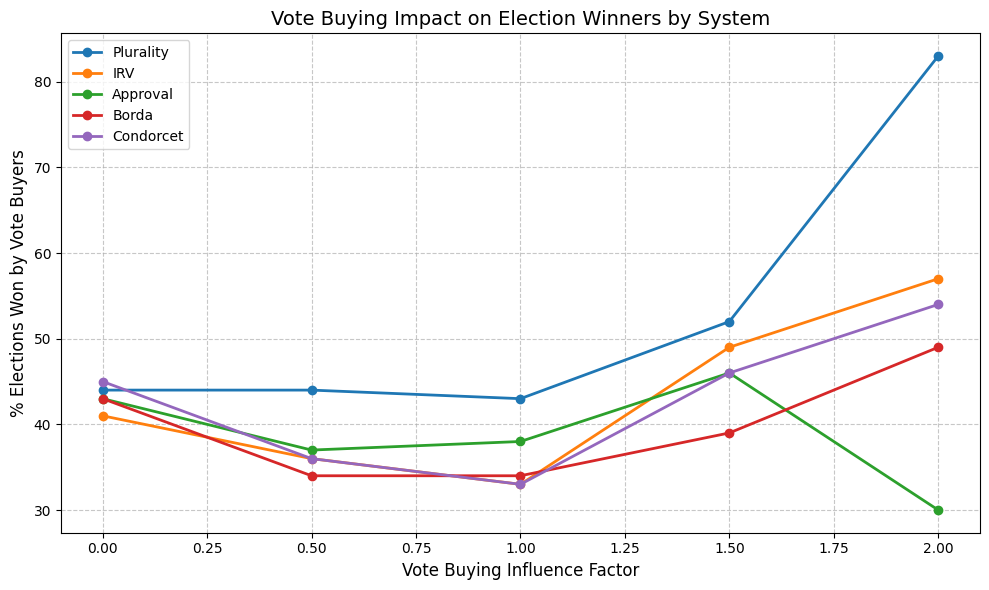

In [32]:
# Execute all visualizations
plot_vote_buying_impact()
plt.show()



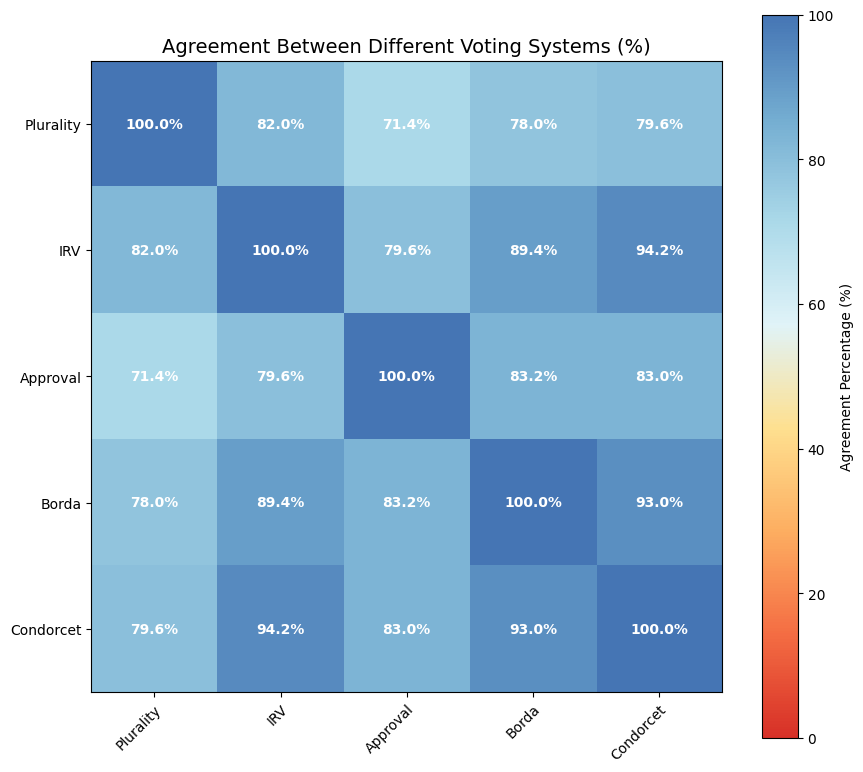

In [33]:

plot_voting_system_agreement()
plt.show()


C:\Users\ajalv\AppData\Local\Temp\ipykernel_16408\1159900574.py:112: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\ajalv\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


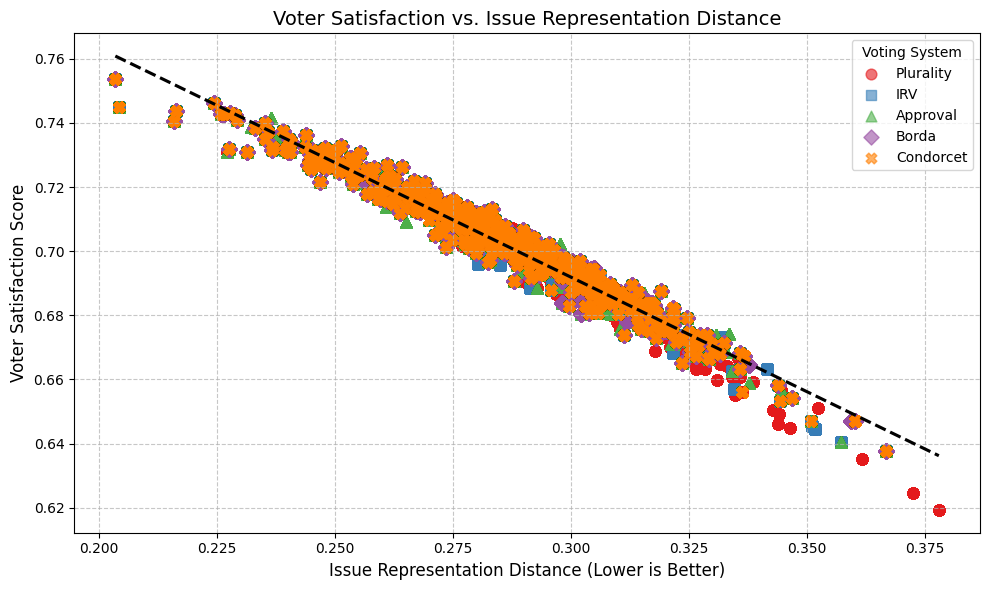

In [34]:

plot_satisfaction_vs_distance()
plt.show()



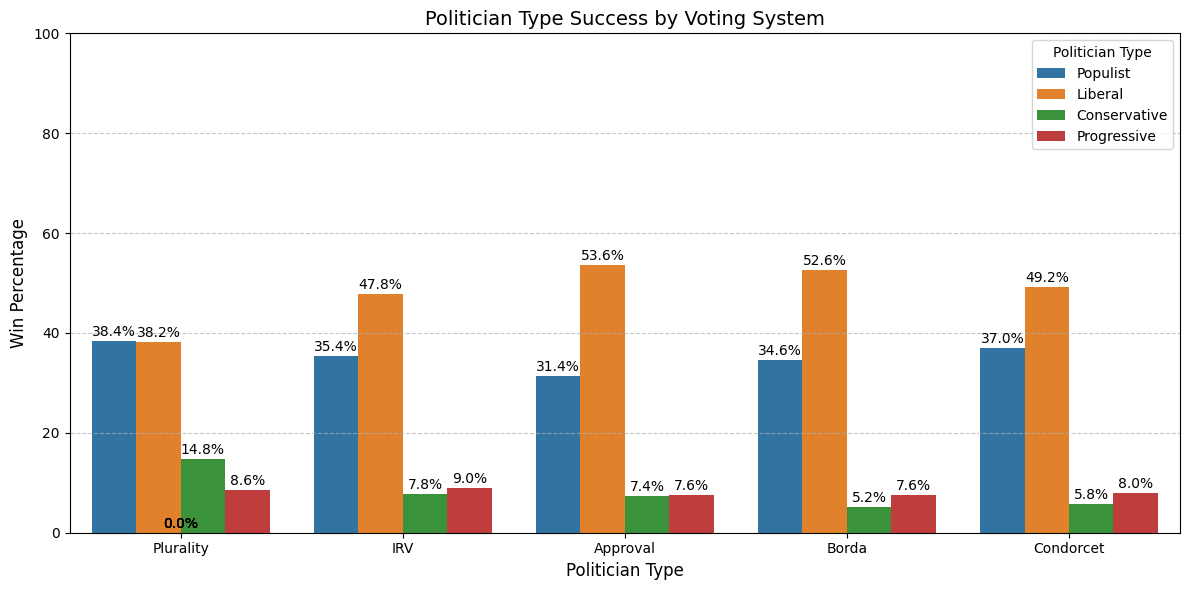

In [35]:
plot_politician_type_bias()
plt.show()

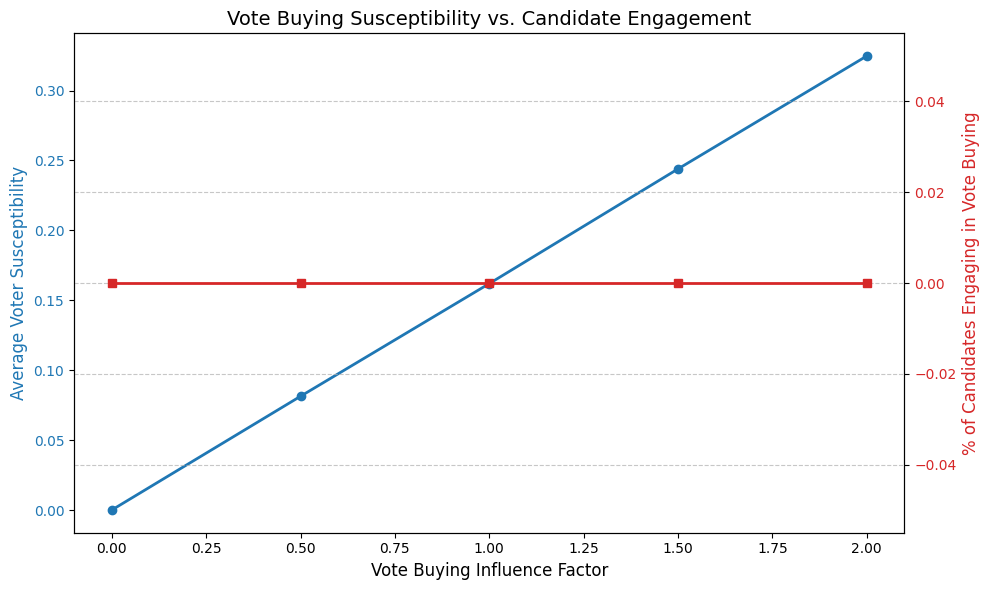

In [36]:
plot_susceptibility_vs_engagement()
plt.show()

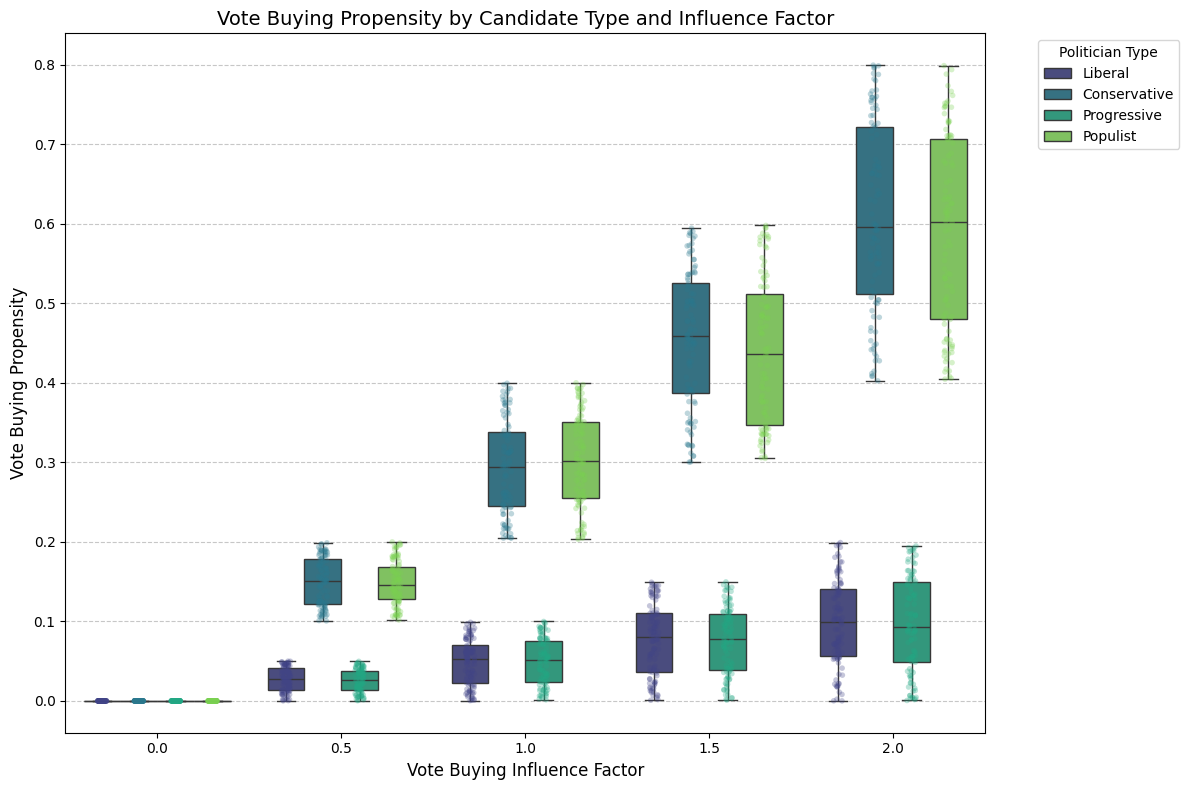

In [37]:
# Create visualization of vote buying propensity by candidate type and influence factor
def plot_vote_buying_propensity_by_type_and_influence():
    # Extract candidate data
    candidates_data = []
    
    for run_id in results_df['RunId'].unique():
        run_data = results_df[results_df['RunId'] == run_id]
        influence = run_data['influence'].iloc[0]
        
        # Get candidate details for this run
        for agent_id in run_data[run_data['AgentType'] == 'Candidate']['AgentID']:
            agent_data = run_data[run_data['AgentID'] == agent_id]
            
            if not agent_data.empty:
                candidates_data.append({
                    'CandidateID': agent_id,
                    'Type': agent_data['Candidate Type'].iloc[0],
                    'Propensity': agent_data['Candidate Propensity'].iloc[0],
                    'Engaged': agent_data['Candidate Engaged in Vote Buying'].iloc[0],
                    'Influence': influence
                })
    
    # Convert to DataFrame
    df = pd.DataFrame(candidates_data)
    
    # Create a visualization showing propensity by type and influence
    plt.figure(figsize=(12, 8))
    
    # Use boxplots to show distribution
    sns.boxplot(x='Influence', y='Propensity', hue='Type', data=df, palette='viridis')
    
    # Add a scatter plot to show individual points
    sns.stripplot(x='Influence', y='Propensity', hue='Type', data=df,
                 size=4, alpha=0.3, dodge=True, palette='viridis', 
                 legend=False)
    
    plt.title('Vote Buying Propensity by Candidate Type and Influence Factor', fontsize=14)
    plt.xlabel('Vote Buying Influence Factor', fontsize=12)
    plt.ylabel('Vote Buying Propensity', fontsize=12)
    plt.legend(title='Politician Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    return plt

# Execute the visualization
plot_vote_buying_propensity_by_type_and_influence()
plt.show()

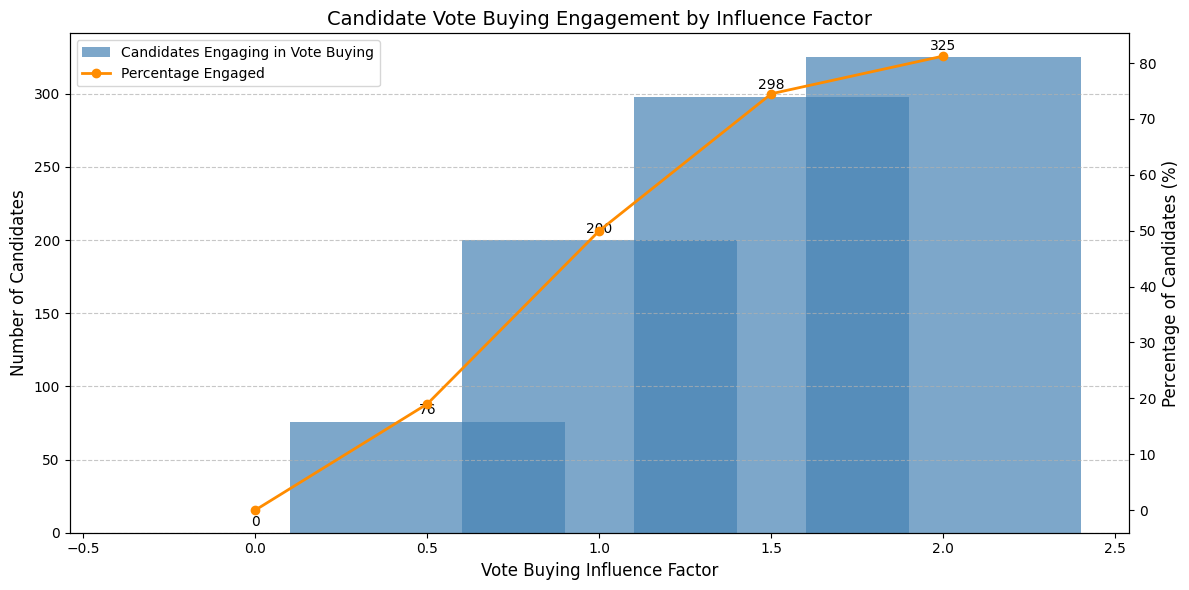

In [38]:
def visualize_vote_buying_engagement_by_influence():
    """
    Create a visualization showing how the influence factor affects 
    the number of candidates who engage in vote buying.
    """
    # Group data by influence factor
    engagement_by_influence = []
    
    # Process each influence level
    for influence_level, group in results_df.groupby('influence'):
        # Get only candidate data
        candidates = group[group['AgentType'] == 'Candidate']
        
        # Count total candidates and those who engaged in vote buying
        total_candidates = len(candidates)
        engaged_candidates = sum(candidates['Candidate Engaged in Vote Buying'] == True)
        
        # Calculate percentage
        percent_engaged = (engaged_candidates / total_candidates) * 100 if total_candidates > 0 else 0
        
        engagement_by_influence.append({
            'Influence': influence_level,
            'Total Candidates': total_candidates,
            'Engaged Candidates': engaged_candidates,
            'Percent Engaged': percent_engaged
        })
    
    # Convert to DataFrame
    engagement_df = pd.DataFrame(engagement_by_influence)
    
    # Create the visualization
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot count of candidates engaged (bars)
    ax1.set_xlabel('Vote Buying Influence Factor', fontsize=12)
    ax1.set_ylabel('Number of Candidates', fontsize=12)
    bars = ax1.bar(engagement_df['Influence'], engagement_df['Engaged Candidates'], 
                  color='steelblue', alpha=0.7, label='Candidates Engaging in Vote Buying')
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')
    
    # Add second y-axis for percentage
    ax2 = ax1.twinx()
    ax2.set_ylabel('Percentage of Candidates (%)', fontsize=12)
    ax2.plot(engagement_df['Influence'], engagement_df['Percent Engaged'], 
            color='darkorange', marker='o', linewidth=2, label='Percentage Engaged')
    
    # Add grid and title
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    plt.title('Candidate Vote Buying Engagement by Influence Factor', fontsize=14)
    
    # Add combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    plt.tight_layout()
    return plt

# Execute the visualization
visualize_vote_buying_engagement_by_influence()
plt.show()

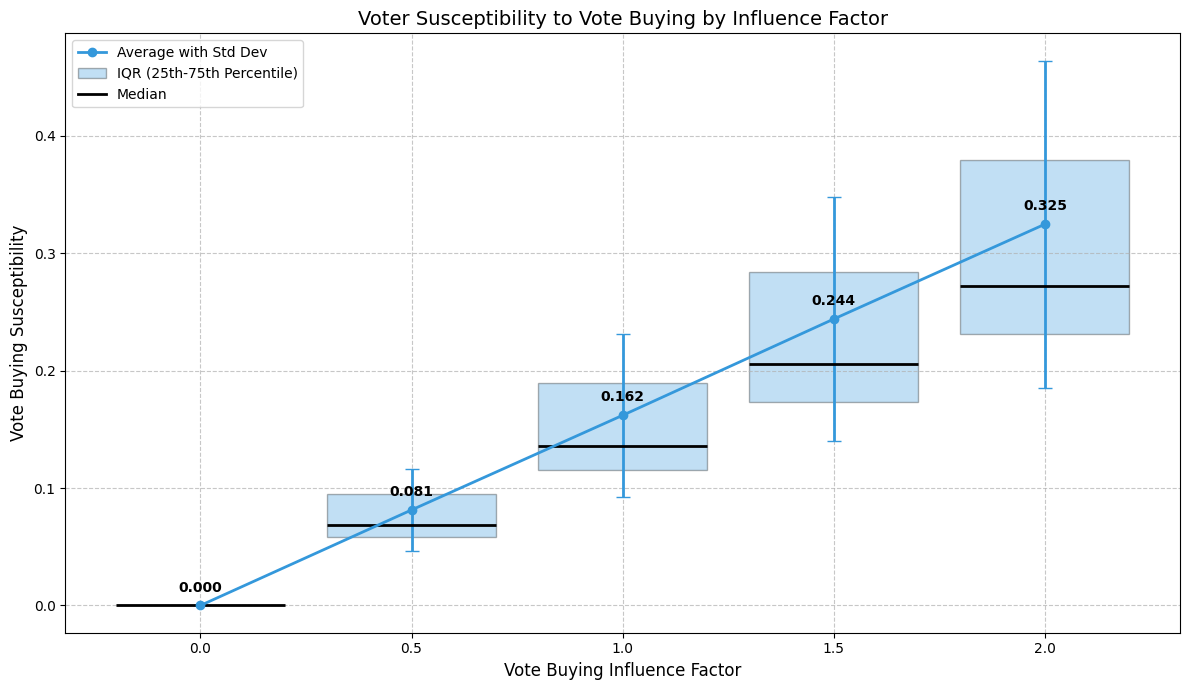

In [39]:
def visualize_voter_susceptibility_by_influence():
    """
    Create a visualization showing how the influence factor affects 
    voter susceptibility to vote buying.
    """
    # Group data by influence factor
    susceptibility_by_influence = []
    
    # Process each influence level
    for influence_level, group in results_df.groupby('influence'):
        # Get only voter data
        voters = group[group['AgentType'] == 'Voter']
        
        # Calculate average susceptibility
        avg_susceptibility = voters['Voter Susceptibility'].mean()
        std_susceptibility = voters['Voter Susceptibility'].std()
        
        # Calculate quartiles for box plot data
        q1 = voters['Voter Susceptibility'].quantile(0.25)
        median = voters['Voter Susceptibility'].median()
        q3 = voters['Voter Susceptibility'].quantile(0.75)
        
        susceptibility_by_influence.append({
            'Influence': influence_level,
            'Average Susceptibility': avg_susceptibility,
            'Std Deviation': std_susceptibility,
            'Q1': q1,
            'Median': median,
            'Q3': q3
        })
    
    # Convert to DataFrame
    susceptibility_df = pd.DataFrame(susceptibility_by_influence)
    
    # Create the visualization
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot average susceptibility with error bars
    ax.errorbar(
        susceptibility_df['Influence'], 
        susceptibility_df['Average Susceptibility'],
        yerr=susceptibility_df['Std Deviation'],
        fmt='o-', 
        capsize=5, 
        linewidth=2,
        color='#3498db',
        label='Average Susceptibility with Std Dev'
    )
    
    # Add box plot elements to show distribution
    for i, row in susceptibility_df.iterrows():
        # Draw box for interquartile range
        rect = plt.Rectangle(
            (row['Influence'] - 0.2, row['Q1']),
            0.4, row['Q3'] - row['Q1'],
            alpha=0.3,
            facecolor='#3498db',
            edgecolor='black'
        )
        ax.add_patch(rect)
        
        # Draw median line
        ax.hlines(y=row['Median'], 
                 xmin=row['Influence'] - 0.2,
                 xmax=row['Influence'] + 0.2,
                 colors='black', 
                 linewidth=2)
    
    # Annotate points with values
    for i, row in susceptibility_df.iterrows():
        ax.annotate(
            f"{row['Average Susceptibility']:.3f}",
            (row['Influence'], row['Average Susceptibility']),
            textcoords="offset points",
            xytext=(0, 10),
            ha='center',
            fontweight='bold'
        )
    
    # Set labels and title
    ax.set_xlabel('Vote Buying Influence Factor', fontsize=12)
    ax.set_ylabel('Vote Buying Susceptibility', fontsize=12)
    ax.set_title('Voter Susceptibility to Vote Buying by Influence Factor', fontsize=14)
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add legend
    box_patch = plt.Rectangle((0,0), 1, 1, alpha=0.3, facecolor='#3498db', edgecolor='black')
    line_patch = plt.Line2D([0], [0], color='black', linewidth=2)
    
    ax.legend(
        [ax.get_lines()[0], box_patch, line_patch], 
        ['Average with Std Dev', 'IQR (25th-75th Percentile)', 'Median'],
        loc='best'
    )
    
    plt.tight_layout()
    return plt

# Execute the visualization
visualize_voter_susceptibility_by_influence()
plt.show()

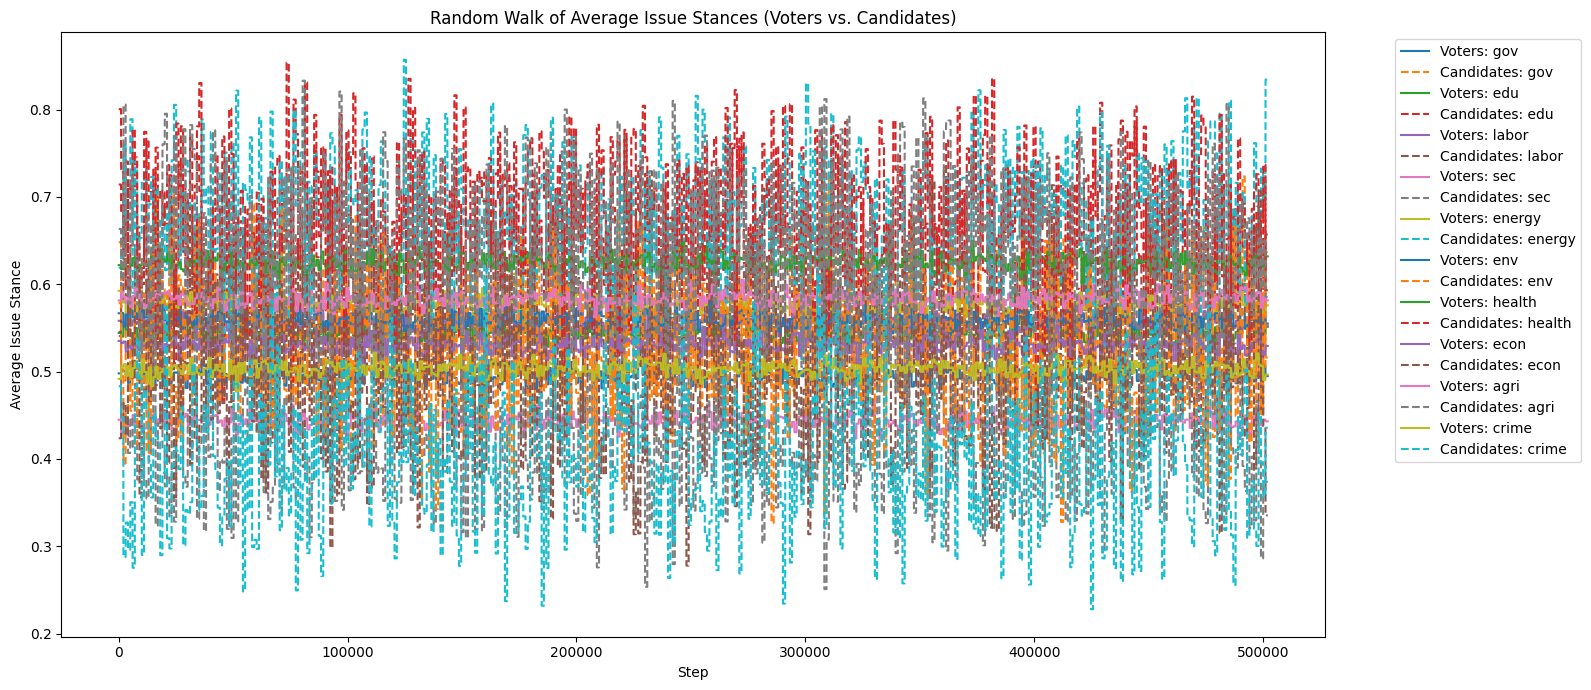

In [40]:
def plot_random_walk_issue_stances(model_data):
    voter_stances = pd.DataFrame(list(model_data["Avg Voter Issue Stances"]))
    candidate_stances = pd.DataFrame(list(model_data["Avg Candidate Issue Stances"]))

    issues = voter_stances.columns
    steps = range(len(voter_stances))

    plt.figure(figsize=(16, 7))
    for issue in issues:
        plt.plot(steps, voter_stances[issue], label=f"Voters: {issue}", linestyle='-')
        plt.plot(steps, candidate_stances[issue], label=f"Candidates: {issue}", linestyle='--')
    plt.xlabel("Step")
    plt.ylabel("Average Issue Stance")
    plt.title("Random Walk of Average Issue Stances (Voters vs. Candidates)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Usage:
plot_random_walk_issue_stances(results_df)